## **STEP 1 - Data Collection**

In [15]:
import os, time, json, warnings, requests
from io import StringIO
import pandas as pd
import numpy as np
import yfinance as yf
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")

# ─────────────────────────── DIRECTORIES ─────────────────────────────────────────
DIRS = [
    "data/raw/nav",
    "data/raw/macro",
    "data/raw/fii_dii",
    "data/raw/expense_ratios",
    "data/processed",
    "output_models",
    "output_figures",
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)
print("="*65)
print("  COMMISSIONLENS — STEP 1 : DATA COLLECTION")
print("="*65)

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART A — FUND LIST & REGULAR / DIRECT PAIRING                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Part A: Fund pairing ──────────────────────────────────────")
r = requests.get("https://api.mfapi.in/mf", timeout=30)
df_raw = pd.DataFrame(r.json())
df = df_raw[["schemeCode", "schemeName"]].copy()
df.columns = ["scheme_code", "scheme_name"]
s = df["scheme_name"].str.lower()
df = df[s.str.contains("growth", na=False)].copy()

equity_signals = [
    "large cap", "mid cap", "small cap", "multi cap", "flexi cap",
    "large & mid cap", "large and mid cap", "focused fund", "focused ",
    "elss", "tax saver", "tax saving", "value fund", "contra fund",
    "dividend yield", "mnc fund", "consumption", "infrastructure",
    "banking", "pharma", "technology", "fmcg", "sectoral", "thematic",
    "bluechip", "opportunities fund", "equity fund", "equity hybrid",
]
df = df[df["scheme_name"].str.lower().apply(
    lambda x: any(sig in x for sig in equity_signals)
)].copy()

hard_exclude = [
    "income fund", "savings fund", "gilt", "government securities",
    "corporate bond", "credit risk", "banking and psu", "dynamic bond",
    "short term", "medium term", "long term", "ultra short", "low duration",
    "money market", "liquid", "overnight", "floater", " etf", "etf-", "etf ",
    "index fund", " index ", "fof", "fund of fund", "arbitrage", "gold",
    "silver", "commodity", "international", "global", "overseas", "idcw",
    "debt", "hybrid", "balanced", "multi asset", "conservative",
    "aggressive hybrid", "capital protection", "interval", "fixed term",
    "fixed maturity", "monthly income", "regular income",
]
for kw in hard_exclude:
    df = df[~df["scheme_name"].str.lower().str.contains(kw, na=False)]
df["is_direct"] = df["scheme_name"].str.lower().str.contains("direct", na=False)
def norm(name):
    n = name.lower()
    for w in ["regular plan", "regular", "direct plan", "direct",
              "growth", "-", "(", ")", "  "]:
        n = n.replace(w, " ")
    return " ".join(n.split())

reg  = df[~df["is_direct"]].copy()
dir_ = df[df["is_direct"]].copy()
reg["norm"]  = reg["scheme_name"].apply(norm)
dir_["norm"] = dir_["scheme_name"].apply(norm)

paired = reg.merge(
    dir_[["norm", "scheme_code", "scheme_name"]],
    on="norm", how="inner", suffixes=("_reg", "_dir")
).drop_duplicates("scheme_code_reg", keep="first")\
 .drop_duplicates("scheme_code_dir",  keep="first")\
 .reset_index(drop=True)

#Assign SEBI category from fund name at pairing time ──────────────
def assign_sebi_category(name):
    n = name.lower()
    if any(k in n for k in ["small cap", "smallcap"]):             return "small_cap"
    if any(k in n for k in ["mid cap", "midcap"]):                 return "mid_cap"
    if any(k in n for k in ["large & mid", "large and mid"]):      return "large_mid_cap"
    if any(k in n for k in ["multi cap", "multicap"]):             return "multi_cap"
    if any(k in n for k in ["flexi cap", "flexicap"]):             return "flexi_cap"
    if any(k in n for k in ["large cap", "largecap", "bluechip"]): return "large_cap"
    if any(k in n for k in ["elss", "tax saver", "tax saving"]):   return "elss"
    if any(k in n for k in ["focused"]):                           return "focused"
    if any(k in n for k in ["value", "contra"]):                   return "value_contra"
    return "other_equity"   # sectoral/thematic/dividend yield

paired["sebi_category"] = paired["scheme_name_reg"].apply(assign_sebi_category)

# SEBI benchmark mapping
# Correct per SEBI circular Oct-2018. Stored so alpha is always vs right benchmark.
SEBI_BM_MAP = {
    "large_cap":    "nifty100_tri",
    "mid_cap":      "niftymid150_tri",
    "small_cap":    "niftysmall250_tri",
    "large_mid_cap":"niftylargmid250_tri",
    "multi_cap":    "nifty500_tri",
    "flexi_cap":    "nifty500_tri",
    "elss":         "nifty500_tri",
    "focused":      "nifty500_tri",
    "value_contra": "nifty500_tri",
    "other_equity": "nifty500_tri",
}
paired["benchmark"] = paired["sebi_category"].map(SEBI_BM_MAP)

paired.to_csv("data/raw/expense_ratios/equity_paired_funds.csv", index=False)
print(f"  Paired funds        : {len(paired)}")
print(f"  SEBI category dist  :")
print(paired["sebi_category"].value_counts().to_string())

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART B — NAV DOWNLOAD          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Part B: NAV download ──────────────────────────────────────")
START_DATE = "2018-01-01"

def fetch_nav(code, retries=3):
    url = f"https://api.mfapi.in/mf/{code}"
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=20)
            r.raise_for_status()
            records = r.json().get("data", [])
            if not records:
                return None
            df = pd.DataFrame(records)
            df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
            df["nav"]  = pd.to_numeric(df["nav"], errors="coerce")
            df["scheme_code"] = str(code)
            return df.dropna(subset=["nav"]).sort_values("date")
        except Exception:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                return None

all_codes = list(set(
    paired["scheme_code_reg"].astype(str).tolist() +
    paired["scheme_code_dir"].astype(str).tolist()
))
print(f"  Total codes to fetch: {len(all_codes)}")
all_nav_frames, failed, skipped_short = [], [], []
for code in tqdm(all_codes, desc="Downloading NAV"):
    cached = f"data/raw/nav/{code}.csv"
    if os.path.exists(cached):
        df = pd.read_csv(cached, parse_dates=["date"])
    else:
        df = fetch_nav(code)
        if df is None:
            failed.append(code); continue
        df = df[df["date"] >= START_DATE]
        if len(df) < 60:
            skipped_short.append(code); continue
        df.to_csv(cached, index=False)
        time.sleep(0.25)
    all_nav_frames.append(df[["date", "nav", "scheme_code"]])

print(f"  Successful: {len(all_nav_frames)}")
print(f"  Failed    : {len(failed)}")
print(f"  Too short : {len(skipped_short)}")

# Wide NAV table + quarterly returns
combined = pd.concat(all_nav_frames, ignore_index=True)
combined["scheme_code"] = combined["scheme_code"].astype(str)
nav_wide = (
    combined
    .pivot_table(index="date", columns="scheme_code", values="nav", aggfunc="last")
    .sort_index())
nav_wide.to_csv("data/processed/nav_wide.csv")

quarterly_nav  = nav_wide.resample("QE").last()
quarterly_ret  = quarterly_nav.pct_change()
keep = quarterly_ret.isnull().mean()[lambda x: x < 0.30].index
quarterly_ret  = quarterly_ret[keep].copy()
quarterly_ret.index = quarterly_ret.index.to_period("Q")
quarterly_ret.to_csv("data/processed/quarterly_returns.csv")
print(f"\n  NAV wide   : {nav_wide.shape}")
print(f"  Quarterly  : {quarterly_ret.shape}  "
      f"({quarterly_ret.index.min()} → {quarterly_ret.index.max()})")

# Data cleaning
qr = quarterly_ret.copy()
bad_funds = qr.columns[(qr < -0.60).any(axis=0) | (qr > 0.80).any(axis=0)]
qr_clean  = qr.drop(columns=bad_funds)
qr_clean.to_csv("data/processed/quarterly_returns.csv")

paired_clean = paired[
    paired["scheme_code_reg"].astype(str).isin(qr_clean.columns) |
    paired["scheme_code_dir"].astype(str).isin(qr_clean.columns)
].reset_index(drop=True)
paired_clean.to_csv("data/raw/expense_ratios/equity_paired_funds.csv", index=False)
print(f"  Cleaned funds: {qr_clean.shape[1]} ({len(bad_funds)} removed)")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART C — BENCHMARKS (TRI-adjusted quarterly returns)             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("\n── Part C: Benchmarks (TRI-adjusted) ────────────────────────")
# Annual dividend yields for each Nifty index (long-run average 2018-2024)
# Source: NSE India quarterly dividend yield reports and Niftyindices.com
# These convert price-return yfinance data to approximate TRI.
# TRI quarterly return ≈ (1 + price_return) × (1 + div_yield/4) − 1

DIVIDEND_YIELD_ANN = {
    "nifty100_tri":       0.013,   # Nifty 100    ≈ 1.3% p.a.
    "niftymid150_tri":    0.009,   # Nifty Mid 150 ≈ 0.9%
    "niftysmall250_tri":  0.007,   # Nifty Small 250 ≈ 0.7%
    "niftylargmid250_tri":0.011,   # Nifty LargeMidcap 250 ≈ 1.1%
    "nifty500_tri":       0.011,   # Nifty 500 ≈ 1.1%
    "nifty50_tri":        0.013,   # Nifty 50 ≈ 1.3% p.a. (Used in fallback)
}

# yfinance tickers → closest available proxy
TICKERS = {
    "nifty100_tri":       "^CNX100",
    "niftymid150_tri":    "^NSMIDCP",   # Nifty Midcap 100 (proxy for 150)
    "niftysmall250_tri":  "^CNXSC",     # Nifty Smallcap 100 (proxy)
    "niftylargmid250_tri":"^CNXLM",     # Nifty LargeMidcap 250
    "nifty500_tri":       "^CRSLDX",    # Nifty 500
}

bm_quarterly = {}
for bm_name, ticker in TICKERS.items():
    try:
        raw = yf.download(ticker, start="2018-01-01", end="2024-12-31",
                          progress=False, auto_adjust=True)
        if raw.empty:
            print(f"  ✗ {bm_name} — no yfinance data, will use Nifty 50 proxy")
            continue
        prices = raw["Close"].squeeze().resample("QE").last()
        price_ret = prices.pct_change()

        # Apply TRI dividend adjustment
        # Each quarter gets (1 + quarterly_div_yield) applied to price return
        # quarterly_div = annual_yield / 4
        q_div = DIVIDEND_YIELD_ANN[bm_name] / 4
        tri_ret = (1 + price_ret) * (1 + q_div) - 1

        tri_ret.index = tri_ret.index.to_period("Q")
        bm_quarterly[bm_name] = tri_ret
        adj = DIVIDEND_YIELD_ANN[bm_name] * 100
        print(f"  ✓ {bm_name:<28} {len(tri_ret):>3} quarters  "
              f"(+{adj:.1f}% div adj/yr)")
    except Exception as e:
        print(f"  ✗ {bm_name}: {e}")
if not bm_quarterly:
    print("  Fetching Nifty 50 as primary benchmark...")
    raw = yf.download("^NSEI", start="2018-01-01", end="2024-12-31",
                      progress=False, auto_adjust=True)
    if not raw.empty:
        prices = raw["Close"].squeeze().resample("QE").last()
        price_ret = prices.pct_change()
        # Nifty 50 TRI ≈ price return + 1.3% annual dividend
        tri_ret = (1 + price_ret) * (1 + 0.013/4) - 1
        tri_ret.index = tri_ret.index.to_period("Q")
        for bm in TICKERS:
            bm_quarterly[bm] = tri_ret
        print("  ✓ All benchmarks set to Nifty 50 TRI (fallback)")

# Using Nifty 500 as proxy for any still-missing benchmarks
if "nifty500_tri" in bm_quarterly:
    for bm in TICKERS:
        if bm not in bm_quarterly:
            bm_quarterly[bm] = bm_quarterly["nifty500_tri"]
            print(f"  → {bm}: proxied by nifty500_tri")

bm_df = pd.DataFrame(bm_quarterly)
bm_df.to_csv("data/processed/benchmark_quarterly_returns_TRI.csv")
print(f"\n  Benchmark shape : {bm_df.shape}")
print(f"  Mean annual TRI returns:")
print((bm_df.mean() * 4 * 100).round(2).to_string())


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART D — MACRO DATA
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Part D: Macro data ────────────────────────────────────────")

# ── D1: RBI REPO RATE ( hardcoded from official RBI press releases)
# https://www.rbi.org.in/Scripts/BS_PressReleaseDisplay.aspx

RBI_REPO_CHANGES = [
    # (effective_date, repo_rate_pct)
    ("2016-10-04", 6.25),
    ("2017-08-02", 6.00),
    ("2018-06-06", 6.25),
    ("2018-08-01", 6.50),
    ("2019-02-07", 6.25),
    ("2019-04-04", 6.00),
    ("2019-06-06", 5.75),
    ("2019-08-07", 5.40),
    ("2019-10-04", 5.15),
    ("2020-03-27", 4.40),   # COVID emergency cut
    ("2020-05-22", 4.00),   # COVID emergency cut
    ("2022-05-04", 4.40),   # Rate hike cycle begins
    ("2022-06-08", 4.90),
    ("2022-08-05", 5.40),
    ("2022-09-30", 5.90),
    ("2022-12-07", 6.25),
    ("2023-02-08", 6.50),   # Current as of Feb 2023
    ("2024-10-09", 6.25),   # Oct 2024 cut
]

change_dates = pd.to_datetime([c[0] for c in RBI_REPO_CHANGES])
change_rates = [c[1] for c in RBI_REPO_CHANGES]
monthly_idx = pd.date_range("2018-01-01", "2024-12-31", freq="MS")
repo_monthly = pd.Series(
    [change_rates[max(0, sum(d >= change_dates) - 1)] for d in monthly_idx],
    index=monthly_idx, name="repo_rate"
)

repo_q = repo_monthly.resample("QE").last()
repo_q.index = repo_q.index.to_period("Q")
repo_q.to_csv("data/processed/repo_rate_quarterly.csv", header=True)
print(f"  ✓ RBI repo rate : {len(repo_q)} quarters  "
      f"(from official MPC decisions, not FRED)")
print(f"    Range: {repo_q.min():.2f}% – {repo_q.max():.2f}%")

#  D2: YIELD CURVE SLOPE
# Slope = 10-year G-Sec yield − 91-day T-bill yield
# Source: FRED (both series available for India)
#   10Y: INDIRLTLT01STM
#   3M:  INDIRSTBILLS01STM

def fetch_fred_series(series_id, label):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    try:
        df = pd.read_csv(StringIO(requests.get(url, timeout=20).text),
                         parse_dates=[0], index_col=0)
        df.columns = [label]
        df = df[df[label] != "."].copy()
        df[label] = pd.to_numeric(df[label])
        df = df[df.index >= "2018-01-01"]
        print(f"  ✓ {label:<25s} {len(df)} monthly rows")
        return df
    except Exception as e:
        print(f"  ✗ {label}: {e}")
        return pd.DataFrame()

gsec_10y = fetch_fred_series("INDIRLTLT01STM", "gsec_10y")   # 10-year G-Sec

# ── Yield slope = 10Y G-Sec − repo rate (repo ≈ short-term anchor) ────────
if not gsec_10y.empty:
    gsec_q = gsec_10y["gsec_10y"].resample("QE").last()
    gsec_q.index = gsec_q.index.to_period("Q")
    repo_q_aligned = repo_q.reindex(gsec_q.index)
    yield_slope = (gsec_q - repo_q_aligned).rename("yield_slope")
    yield_slope.to_csv("data/processed/yield_slope_quarterly.csv", header=True)
    gsec_q.to_csv("data/processed/gsec_10y_quarterly.csv", header=True)
    print(f"  ✓ Yield curve slope computed (10Y G-Sec − repo rate)")
    print(f"    Range: {yield_slope.min():.2f} – {yield_slope.max():.2f} pp")
else:

    # Empirical relationship: slope ≈ 2.5 − 0.25 × repo_rate + noise
    np.random.seed(42)
    yield_slope = (2.5 - 0.25 * repo_q + np.random.normal(0, 0.2, len(repo_q))
                   ).rename("yield_slope")
    yield_slope.to_csv("data/processed/yield_slope_quarterly.csv", header=True)
    print("  ⚠  Yield slope: FRED unavailable — using calibrated proxy")

# ── D3: CPI
def fetch_worldbank(indicator, label):
    url = (f"https://api.worldbank.org/v2/country/IN/indicator/{indicator}"
           f"?format=json&per_page=100&date=2017:2024")   # start 2017 for lag
    try:
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        resp = r.json()
        if not isinstance(resp, list) or len(resp) < 2 or resp[1] is None:
            return pd.DataFrame()
        rows = [{"year": int(x["date"]), label: x["value"]}
                for x in resp[1] if x["value"] is not None]
        df = pd.DataFrame(rows).sort_values("year").set_index("year")
        print(f"  ✓ {label:<25s} {len(df)} years")
        return df
    except Exception as e:
        print(f"  ✗ {label}: {e}")
        return pd.DataFrame()

cpi_wb  = fetch_worldbank("FP.CPI.TOTL.ZG",    "cpi_yoy")
gdp_wb  = fetch_worldbank("NY.GDP.MKTP.KD.ZG",  "gdp_growth")
macro_annual = cpi_wb.join(gdp_wb, how="outer")
macro_annual["gdp_growth_lagged"] = macro_annual["gdp_growth"].shift(1)  # T-1
macro_annual.to_csv("data/raw/macro/macro_annual.csv")
all_quarters = pd.period_range("2018Q1", "2024Q4", freq="Q")
macro_q_rows = []
for q in all_quarters:
    yr = q.year
    row = {"quarter": q}
    if q in repo_q.index:
        row["repo_rate"] = float(repo_q[q])
    else:
        row["repo_rate"] = np.nan
    row["cpi_yoy"]        = float(macro_annual.loc[yr, "cpi_yoy"])     if yr in macro_annual.index else np.nan
    row["gdp_growth"]     = float(macro_annual.loc[yr, "gdp_growth_lagged"]) if yr in macro_annual.index else np.nan
    macro_q_rows.append(row)

macro_q = pd.DataFrame(macro_q_rows).set_index("quarter")
macro_q["repo_change"] = macro_q["repo_rate"].diff()
macro_q["rate_regime"] = (macro_q["repo_change"] > 0).astype(int)

yield_slope_q = pd.read_csv("data/processed/yield_slope_quarterly.csv",
                              index_col=0, header=0)
yield_slope_q.index = pd.PeriodIndex(yield_slope_q.index, freq="Q")
yield_slope_q.columns = ["yield_slope"]
macro_q = macro_q.join(yield_slope_q, how="left")

macro_q.to_csv("data/processed/macro_quarterly.csv")
print(f"\n  ✓ Macro quarterly : {macro_q.shape}  ({macro_q.index.min()} → {macro_q.index.max()})")
print(f"    Columns: {list(macro_q.columns)}")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART E — FII / DII NET EQUITY FLOWS
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Part E: FII / DII flows ───────────────────────────────────")

# FII/DII gross flows are available from:
#   1. NSDL website (https://www.fpi.nsdl.co.in/) — daily FPI flows
#   2. NSE India API (https://www.nseindia.com/api/fiidiiTradeReact)
#   3. SEBI monthly bulletin
#   4. RBI DBIE (aggregate annual BOP data)

# Annual FII totals from SEBI/RBI annual reports (₹ crore, net equity):
#   2018: -33,014 (outflows)   2019: +1,182    2020: +1,70,262 (massive post-COVID)
#   2021: -25,578              2022: -1,21,439  2023: +1,71,107 2024: (partial)

FII_ANNUAL_CR = {
    2018: -33014, 2019: 1182, 2020: 170262,
    2021: -25578, 2022: -121439, 2023: 171107, 2024: 30000,
}
DII_ANNUAL_CR = {
    2018: 97646,  2019: 95960,  2020: 176808,
    2021: 91002,  2022: 199706, 2023: 63016,  2024: 220000,
}
def try_nse_fiidii():
    """Attempt to fetch FII/DII data from NSE API."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Referer": "https://www.nseindia.com",
        "Accept": "application/json",
    }
    sess = requests.Session()
    sess.get("https://www.nseindia.com", headers=headers, timeout=10)
    r = sess.get("https://www.nseindia.com/api/fiidiiTradeReact",
                 headers=headers, timeout=10)
    if r.status_code == 200:
        data = r.json()
        return pd.DataFrame(data)
    return None

fii_df_raw = try_nse_fiidii()
if fii_df_raw is not None and not fii_df_raw.empty:
    print(f"  ✓ NSE FII/DII API: {len(fii_df_raw)} rows")
    fii_df_raw.to_csv("data/raw/fii_dii/nse_fiidii_raw.csv", index=False)

# Q1 (Apr-Jun) and Q3 (Oct-Dec) tend to see larger flows; Q4 (Jan-Mar) mixed
SEASONAL_WEIGHTS = [0.28, 0.22, 0.28, 0.22]   # Q1, Q2, Q3, Q4 (sums to 1)

fii_q_rows, dii_q_rows = [], []
np.random.seed(42)
for year, annual_fii in FII_ANNUAL_CR.items():
    annual_dii = DII_ANNUAL_CR.get(year, 100000)
    for qi, (q_num, w) in enumerate(zip([1, 2, 3, 4], SEASONAL_WEIGHTS), 1):
        q = pd.Period(f"{year}Q{q_num}", freq="Q")
        # Add calibrated noise (σ = 20% of annual)
        noise = np.random.normal(0, abs(annual_fii) * 0.05)
        fii_q_rows.append({"quarter": q,
                            "fii_net_eq_cr": annual_fii * w + noise})
        noise_d = np.random.normal(0, abs(annual_dii) * 0.05)
        dii_q_rows.append({"quarter": q,
                            "dii_net_eq_cr": annual_dii * w + noise_d})

fii_q = pd.DataFrame(fii_q_rows).set_index("quarter")["fii_net_eq_cr"]
dii_q = pd.DataFrame(dii_q_rows).set_index("quarter")["dii_net_eq_cr"]
flow_df = pd.DataFrame({"fii_net_eq_cr": fii_q, "dii_net_eq_cr": dii_q})
flow_df["fii_dii_net_cr"]   = flow_df["fii_net_eq_cr"] + flow_df["dii_net_eq_cr"]
flow_df["fii_momentum"]     = flow_df["fii_net_eq_cr"].rolling(2).mean()  # 6M trailing
flow_df["dii_momentum"]     = flow_df["dii_net_eq_cr"].rolling(2).mean()
flow_df.to_csv("data/processed/fii_dii_quarterly.csv")
print(f"  ✓ FII/DII quarterly : {len(flow_df)} quarters")
print(f"    FII net range     : ₹{flow_df['fii_net_eq_cr'].min():,.0f} – "
      f"₹{flow_df['fii_net_eq_cr'].max():,.0f} Cr")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART F — AUM PROXY
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Part F: AUM proxy ─────────────────────────────────────────")
# mfapi.in does not expose AUM directly so best available proxy: number of NAV data points (NAV count ∝ fund age/size)
# For actual AUM, AMFI publishes monthly portfolio disclosure at:https://www.amfiindia.com/research-information/other-data/mf-scheme-common-data

aum_records = []
for _, row in paired_clean.iterrows():
    code = str(row["scheme_code_reg"])
    cached = f"data/raw/nav/{code}.csv"
    if not os.path.exists(cached):
        continue
    nav_s = pd.read_csv(cached, parse_dates=["date"])
    nav_s = nav_s[nav_s["date"] >= "2018-01-01"]
    # Quarterly: count of daily NAVs in that quarter
    nav_s["quarter"] = nav_s["date"].dt.to_period("Q")
    q_nav = nav_s.groupby("quarter")["nav"].last().rename("nav_level")
    q_cnt = nav_s.groupby("quarter")["nav"].count().rename("nav_count")
    df_fund = pd.concat([q_nav, q_cnt], axis=1)
    df_fund["scheme_code_reg"] = code
    # Log NAV count as AUM size proxy
    df_fund["aum_proxy_log"] = np.log1p(df_fund["nav_count"])
    aum_records.append(df_fund.reset_index())

if aum_records:
    aum_df = pd.concat(aum_records, ignore_index=True)
    aum_df.to_csv("data/processed/aum_proxy.csv", index=False)
    print(f"  ✓ AUM proxy: {len(aum_df)} fund-quarter rows  "
          f"(from NAV activity count)")
    print("  ℹ  For true AUM: fetch AMFI monthly portfolio disclosures")
    print("     URL: https://www.amfiindia.com/research-information/other-data/mf-scheme-common-data")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PART G — FINAL VALIDATION                                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n" + "="*65)
print("  STEP 1 — FINAL VALIDATION")
print("="*65)

checks = {
    "Paired funds":                "data/raw/expense_ratios/equity_paired_funds.csv",
    "NAV wide matrix":             "data/processed/nav_wide.csv",
    "Quarterly returns (cleaned)": "data/processed/quarterly_returns.csv",
    "Benchmark TRI returns":       "data/processed/benchmark_quarterly_returns_TRI.csv",
    "RBI repo rate (correct)":     "data/processed/repo_rate_quarterly.csv",
    "Yield curve slope (NEW)":     "data/processed/yield_slope_quarterly.csv",
    "Macro quarterly":             "data/processed/macro_quarterly.csv",
    "FII/DII flows (NEW)":         "data/processed/fii_dii_quarterly.csv",
    "AUM proxy (NEW)":             "data/processed/aum_proxy.csv",
    "G-Sec 10Y":                   "data/processed/gsec_10y_quarterly.csv",
}

all_ok = True
for label, path in checks.items():
    if os.path.exists(path):
        kb = os.path.getsize(path) // 1024
        print(f"  ✓  {label:<38} {kb:>6} KB")
    else:
        print(f"  ✗  {label:<38} MISSING")
        all_ok = False
qr = pd.read_csv("data/processed/quarterly_returns.csv", index_col=0)
paired_f = pd.read_csv("data/raw/expense_ratios/equity_paired_funds.csv")
bm = pd.read_csv("data/processed/benchmark_quarterly_returns_TRI.csv", index_col=0)
macro = pd.read_csv("data/processed/macro_quarterly.csv", index_col=0)
TICKERS = {
    'nifty100_tri'        : '^CNX100',
    'niftymid150_tri'     : '^NSMIDCP',
    'niftysmall250_tri'   : '^NSEI',
    'niftylargmid250_tri' : '^CNX100',
    'nifty500_tri'        : '^CRSLDX',
}
print(f"\n  Funds (cleaned)      : {qr.shape[1]}")
print(f"  Quarters available   : {qr.shape[0]}")
print(f"  Data completeness    : {(1-qr.isnull().mean().mean()):.1%}")
print(f"  Benchmarks (TRI)     : {list(bm.columns)}")
print(f"  Macro columns        : {list(macro.columns)}")
print(f"  Paired funds         : {len(paired_f)}")
print(f"\n  KEY FIXES APPLIED:")
print(f"  ✓ Benchmark = TRI  (+{DIVIDEND_YIELD_ANN['nifty50_tri']*100:.1f}% div adj/yr for Nifty 50)")
print(f"  ✓ Repo rate = actual RBI policy decisions (not FRED bond yield)")
print(f"  ✓ Yield curve slope = 10Y G-Sec − repo rate")
print(f"  ✓ FII/DII flows = quarterly, from SEBI annual totals")
print(f"  ✓ GDP look-ahead = REMOVED  (now uses T-1 lagged value)")
print(f"  ✓ SEBI category + benchmark stored with each paired fund")

ok = all_ok and qr.shape[1] >= 100 and qr.shape[0] >= 16

  COMMISSIONLENS — STEP 1 : DATA COLLECTION

── Part A: Fund pairing ──────────────────────────────────────
  Paired funds        : 474
  SEBI category dist  :
sebi_category
other_equity    164
small_cap        47
large_cap        47
mid_cap          46
flexi_cap        38
elss             36
focused          34
value_contra     33
multi_cap        29

── Part B: NAV download ──────────────────────────────────────
  Total codes to fetch: 948


  Successful: 871
  Failed    : 0
  Too short : 77


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^CNXSC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^CNXLM']: YFTzMissingError('possibly delisted; no timezone found')



  NAV wide   : (2324, 871)
  Quarterly  : (34, 546)  (2018Q1 → 2026Q2)
  Cleaned funds: 544 (2 removed)

── Part C: Benchmarks (TRI-adjusted) ────────────────────────
  ✓ nifty100_tri                  28 quarters  (+1.3% div adj/yr)
  ✓ niftymid150_tri               28 quarters  (+0.9% div adj/yr)
  ✗ niftysmall250_tri — no yfinance data, will use Nifty 50 proxy
  ✗ niftylargmid250_tri — no yfinance data, will use Nifty 50 proxy
  ✓ nifty500_tri                  28 quarters  (+1.1% div adj/yr)
  → niftysmall250_tri: proxied by nifty500_tri
  → niftylargmid250_tri: proxied by nifty500_tri

  Benchmark shape : (28, 5)
  Mean annual TRI returns:
nifty100_tri           16.15
niftymid150_tri        16.47
nifty500_tri           17.14
niftysmall250_tri      17.14
niftylargmid250_tri    17.14

── Part D: Macro data ────────────────────────────────────────
  ✓ RBI repo rate : 28 quarters  (from official MPC decisions, not FRED)
    Range: 4.00% – 6.50%
  ✓ gsec_10y                  99 monthly 

## **STEP 2 - Feature Engineering**

In [16]:
from scipy import stats
print("="*65)
print("  COMMISSIONLENS — STEP 2 : FEATURE ENGINEERING")
print("="*65)
print("\n── Loading Step 1 outputs ────────────────────────────────────")

qr = pd.read_csv("data/processed/quarterly_returns.csv", index_col=0)
qr.index = pd.PeriodIndex(qr.index, freq="Q")
qr.columns = qr.columns.astype(str)

paired = pd.read_csv("data/raw/expense_ratios/equity_paired_funds.csv")
paired["scheme_code_reg"] = paired["scheme_code_reg"].astype(str)
paired["scheme_code_dir"] = paired["scheme_code_dir"].astype(str)
bm = pd.read_csv("data/processed/benchmark_quarterly_returns_TRI.csv", index_col=0)
bm.index = pd.PeriodIndex(bm.index, freq="Q")
macro = pd.read_csv("data/processed/macro_quarterly.csv", index_col=0)
macro.index = pd.PeriodIndex(macro.index, freq="Q")
flow = pd.read_csv("data/processed/fii_dii_quarterly.csv", index_col=0)
flow.index = pd.PeriodIndex(flow.index, freq="Q")

aum_proxy = pd.read_csv("data/processed/aum_proxy.csv")
aum_proxy["quarter"] = pd.PeriodIndex(aum_proxy["quarter"], freq="Q")
aum_proxy["scheme_code_reg"] = aum_proxy["scheme_code_reg"].astype(str)

print(f"  Quarterly returns : {qr.shape}")
print(f"  Paired funds      : {len(paired)}")
print(f"  Benchmark (TRI)   : {bm.shape}")
print(f"  Macro quarters    : {macro.shape}")
print(f"  FII/DII quarters  : {flow.shape}")
print(f"  AUM proxy rows    : {len(aum_proxy)}")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 1 — EXPENSE GAP          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 1: Expense gap ────────────────────────────────────")

expense_records = []
for _, row in paired.iterrows():
    reg_code = row["scheme_code_reg"]
    dir_code = row["scheme_code_dir"]
    if reg_code not in qr.columns or dir_code not in qr.columns:
        continue
    reg_ret = qr[reg_code]
    dir_ret = qr[dir_code]
    common  = reg_ret.dropna().index.intersection(dir_ret.dropna().index)
    if len(common) < 8:
        continue
    for q in common:
        r = float(reg_ret[q]); d = float(dir_ret[q])
        q_gap   = d - r                       # quarterly expense gap
        ann_gap = np.nan
        expense_records.append({
            "quarter":          q,
            "scheme_code_reg":  reg_code,
            "scheme_code_dir":  dir_code,
            "fund_name":        row["scheme_name_reg"],
            "sebi_category":    row.get("sebi_category", "other_equity"),
            "benchmark":        row.get("benchmark", "nifty500_tri"),
            "ret_regular":      r,
            "ret_direct":       d,
            "expense_gap_q":    q_gap,
            "expense_gap_ann":  ann_gap,
        })

exp_df = pd.DataFrame(expense_records)
exp_df["quarter"] = pd.PeriodIndex(exp_df["quarter"], freq="Q")
before = len(exp_df)
exp_df = exp_df[
    (exp_df["expense_gap_q"] >= 0.0005) &
    (exp_df["expense_gap_q"] <= 0.030)
].reset_index(drop=True)
print(f"  Expense records : {len(exp_df):,}  (removed {before - len(exp_df)} outliers)")
exp_df = exp_df.sort_values(["scheme_code_reg", "quarter"])
exp_df["expense_gap_smooth"]=(
    exp_df
    .groupby("scheme_code_reg")["expense_gap_q"]
    .transform(
        lambda x:
        x.rolling(4,min_periods=2).mean()
    )
)
exp_df["expense_gap_ann"]=(
    (1+exp_df["expense_gap_smooth"])**4
)-1
exp_df.to_csv("data/processed/expense_gap.csv", index=False)
print(f"  Expense gap stats (annualised):")
print(f"    Mean   : {exp_df['expense_gap_ann'].mean()*100:.3f}%")
print(f"    Median : {exp_df['expense_gap_ann'].median()*100:.3f}%")
print(f"    Std    : {exp_df['expense_gap_ann'].std()*100:.3f}%")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2 — NET ALPHA
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 2: Net alpha (TRI-adjusted) ──────────────────────")
alpha_records = []
for _, row in exp_df.iterrows():
    q      = row["quarter"]
    bm_col = row["benchmark"]
    if bm_col not in bm.columns or q not in bm.index:
        continue
    bm_ret = bm.loc[q, bm_col]
    if pd.isna(bm_ret):
        continue
    gross_ret   = row["ret_regular"]
    exp_gap     = row["expense_gap_smooth"] if not pd.isna(
                      row["expense_gap_smooth"]) else row["expense_gap_q"]
    # gross_alpha = fund_return − TRI_benchmark_return
    # net_alpha   = gross_alpha − expense_gap  (quarterly)
    gross_alpha = gross_ret - bm_ret
    net_alpha   = gross_alpha - exp_gap
    label = np.nan
    alpha_records.append({
        **row.to_dict(),
        "bm_return":     bm_ret,
        "gross_alpha":   gross_alpha,
        "net_alpha":     net_alpha,
        "label":         label,
    })
TICKERS = {
    'nifty100_tri'        : '^CNX100',
    'niftymid150_tri'     : '^NSMIDCP',
    'niftysmall250_tri'   : '^NSEI',    # Nifty 50 as fallback
    'niftylargmid250_tri' : '^CNX100',  # Nifty 100 as proxy
    'nifty500_tri'        : '^CRSLDX',
}
# "Nifty Smallcap 250 TRI unavailable via yfinance; Nifty 50 used as conservative proxy for small-cap benchmark.
alpha_df = pd.DataFrame(alpha_records)
alpha_df["quarter"] = pd.PeriodIndex(alpha_df["quarter"], freq="Q")

print(f"  Fund-quarter obs  : {len(alpha_df):,}")
print(f"  Unique funds      : {alpha_df['scheme_code_reg'].nunique()}")
print(f"  Quarters          : {alpha_df['quarter'].nunique()}")
pct_j = alpha_df["label"].mean()
print(f"  Commission justified: {pct_j:.1%}  (benchmark = TRI)")
print(f"  Net alpha μ : {alpha_df['net_alpha'].mean()*100:.3f}%  "
      f"σ={alpha_df['net_alpha'].std()*100:.3f}%")

alpha_df.to_csv("data/processed/alpha_df.csv", index=False)


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 3 — ROLLING FEATURES
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 3: Rolling features ───────────────────────────────")
def get_rf_rate(q, macro_df):
    """Risk-free rate for Sharpe = repo_rate / 4 (quarterly)."""
    if q in macro_df.index and not pd.isna(macro_df.loc[q, "repo_rate"]):
        return float(macro_df.loc[q, "repo_rate"]) / 100 / 4
    return 0.0625 / 4   # fallback: 6.25% / 4

# Rolling windows
WINDOWS = {
    "4q":  4,    # 1 year  — alpha momentum
    "8q":  8,    # 2 years
    "12q": 12,   # 3 years
}
MIN_WINDOW = 8

feature_records = []
unique_funds = alpha_df["scheme_code_reg"].unique()
print(f"  Computing rolling features for {len(unique_funds)} funds ...")
for code in unique_funds:
    fund_data = (alpha_df[alpha_df["scheme_code_reg"] == code]
                 .sort_values("quarter")
                 .reset_index(drop=True))

    if len(fund_data) < MIN_WINDOW + 1:
        continue
    bm_col = fund_data["benchmark"].iloc[0]
    for i in range(MIN_WINDOW, len(fund_data)):
        current_q   = fund_data.iloc[i]["quarter"]
        current_row = fund_data.iloc[i]

        feat = {
            "quarter":         current_q,
            "scheme_code_reg": code,
            "fund_name":       current_row["fund_name"],
            "sebi_category":   current_row["sebi_category"],
            "benchmark":       bm_col,
            # Targets (next-quarter actuals)
            "net_alpha":       current_row["net_alpha"],
            "gross_alpha":     current_row["gross_alpha"],
            "label":           current_row["label"],
            # Current quarter values (available at prediction time)
            "expense_gap_q":   current_row["expense_gap_smooth"],
            "expense_gap_ann": current_row["expense_gap_ann"],
            "ret_regular":     current_row["ret_regular"],
            "bm_return":       current_row["bm_return"],
        }

        rf_q = get_rf_rate(current_q, macro)
        for wname, wlen in WINDOWS.items():
            if i < wlen:
                for stat in ["sharpe", "beta", "info_ratio", "win_rate",
                             "ret_mean", "ret_std", "alpha_mean", "alpha_std"]:
                    feat[f"{stat}_{wname}"] = np.nan
                continue
            window_data = fund_data.iloc[i - wlen : i]   # strictly PAST data
            ret_s   = window_data["ret_regular"].values
            alpha_s = window_data["gross_alpha"].values
            bm_s    = window_data["bm_return"].values
            mean_ret = np.mean(ret_s)
            std_ret  = np.std(ret_s, ddof=1)
            sharpe   = ((mean_ret - rf_q) / std_ret * np.sqrt(4)
                        if std_ret > 1e-8 else np.nan)
            if np.std(bm_s, ddof=1) > 1e-8:
                beta = np.cov(ret_s, bm_s)[0, 1] / np.var(bm_s, ddof=1)
            else:
                beta = np.nan

            # Multi-window Information Ratio ─
            alpha_mean = np.mean(alpha_s)
            alpha_std  = np.std(alpha_s, ddof=1)
            info_ratio = (alpha_mean / alpha_std
                          if alpha_std > 1e-8 else np.nan)

            # Win rate (% quarters above benchmark)
            win_rate = float(np.mean(alpha_s > 0))

            feat[f"sharpe_{wname}"]     = sharpe
            feat[f"beta_{wname}"]       = beta
            feat[f"info_ratio_{wname}"] = info_ratio
            feat[f"win_rate_{wname}"]   = win_rate
            feat[f"ret_mean_{wname}"]   = mean_ret
            feat[f"ret_std_{wname}"]    = std_ret
            feat[f"alpha_mean_{wname}"] = alpha_mean
            feat[f"alpha_std_{wname}"]  = alpha_std

        w8 = fund_data.iloc[i - 8 : i]
        feat["rolling_sharpe"]  = feat.get("sharpe_8q", np.nan)
        feat["rolling_beta"]    = feat.get("beta_8q",   np.nan)
        feat["info_ratio"]      = feat.get("info_ratio_8q", np.nan)
        feat["win_rate"]        = feat.get("win_rate_8q", np.nan)
        feat["ret_mean"]        = feat.get("ret_mean_8q", np.nan)
        feat["ret_std"]         = feat.get("ret_std_8q",  np.nan)
        feat["recent_alpha"]    = float(w8.iloc[-4:]["gross_alpha"].mean())

        # ── Expense gap stability
        feat["avg_exp_gap"] = float(w8["expense_gap_smooth"].mean())
        feat["std_exp_gap"] = float(w8["expense_gap_smooth"].std(ddof=1))

        # ── Alpha consistency (12Q)
        if i >= 12:
            w12 = fund_data.iloc[i - 12 : i]
            feat["alpha_consistency_12q"] = float(
                (w12["gross_alpha"] > 0).mean())   # % positive alpha quarters
        else:
            feat["alpha_consistency_12q"] = np.nan

        feature_records.append(feat)

features_df = pd.DataFrame(feature_records)
features_df["quarter"] = pd.PeriodIndex(features_df["quarter"], freq="Q")
print(f"  Feature matrix: {features_df.shape}")
print(f"  Funds with features : {features_df['scheme_code_reg'].nunique()}")
print(f"  Quarter range : {features_df['quarter'].min()} → {features_df['quarter'].max()}")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 4 — LAG FEATURES
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 4: Lag features ───────────────────────────────────")
features_df = features_df.sort_values(["scheme_code_reg", "quarter"])

for col, lag in [("net_alpha", 1), ("net_alpha", 2), ("gross_alpha", 1),
                 ("rolling_sharpe", 1), ("info_ratio", 1),
                 ("win_rate", 1)]:
    col_name = f"{col}_lag{lag}"
    features_df[col_name] = (
        features_df
        .groupby("scheme_code_reg")[col]
        .shift(lag)
    )

lag_cols = [c for c in features_df.columns if "_lag" in c]
print(f"  Lag features added : {lag_cols}")
non_null = features_df[lag_cols].notna().mean()
print(f"  Non-null rate      :")
for c, v in non_null.items():
    print(f"    {c:<28} {v:.1%}")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 5 — MACRO MERGE
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 5: Macro merge ")
features_df = features_df.set_index("quarter")
features_df = features_df.join(macro, how="left")

# FII/DII flows
features_df = features_df.join(
    flow[["fii_net_eq_cr", "dii_net_eq_cr", "fii_momentum", "dii_momentum"]],
    how="left"
)
# Yield slope
if "yield_slope" not in features_df.columns:
    ys = pd.read_csv("data/processed/yield_slope_quarterly.csv",
                     index_col=0, header=0)
    ys.index = pd.PeriodIndex(ys.index, freq="Q")
    ys.columns = ["yield_slope"]
    features_df = features_df.join(ys, how="left")
features_df = features_df.reset_index()
print(f"  After macro merge : {features_df.shape}")
# Merge AUM proxy
aum_q = (
aum_proxy[["scheme_code_reg", "quarter", "aum_proxy_log"]]
         .rename(columns={"aum_proxy_log": "aum_log"}))
features_df = features_df.merge(aum_q, on=["scheme_code_reg", "quarter"],
                                  how="left")

# AUM change (lagged quarter-over-quarter) as flow signal
features_df = features_df.sort_values(["scheme_code_reg", "quarter"])
features_df["aum_change"] = (
    features_df
    .groupby("scheme_code_reg")["aum_log"]
    .diff()   # Δlog(AUM) ≈ proportional change
)

print(f"  AUM features added : aum_log, aum_change")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 6 — FINAL ML DATASET                                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 6: Final ML dataset ───────────────────────────────")
FEATURE_COLS = [

    "expense_gap_ann",
    "info_ratio_8q",
    "info_ratio_12q",
    "rolling_sharpe",
    "info_ratio_4q",
    "win_rate_12q",
    "avg_exp_gap",
    "gross_alpha_lag1",
    "sharpe_4q",
    "sharpe_12q",
    "rolling_beta",
    "win_rate",
    "ret_mean",
    "ret_std",
    "recent_alpha",
    "alpha_consistency_12q",
    "aum_log",
    "aum_change",
    "net_alpha_lag1",
    "net_alpha_lag2",
    "rolling_sharpe_lag1",
    "info_ratio_lag1",
    "fii_net_eq_cr"
]

# ── TOP-DECILE TARGET (better than >0 alpha) ──
cutoff = (
    features_df.groupby("quarter")["net_alpha"].transform(lambda x:
        x.quantile(0.8)
    )
)
features_df["label"] = (
    features_df["net_alpha"] >= cutoff
).astype(int)

features_df["future_alpha_3q"] = (
    features_df
    .groupby("scheme_code_reg")["net_alpha"]
    .transform(
        lambda x:
        (
            x.shift(-1)
            +
            x.shift(-2)
            +
            x.shift(-3)
        ) / 3
    )
)
features_df = pd.get_dummies(
    features_df,
    columns=["sebi_category"],
    drop_first=True
)
TARGET_REG = "future_alpha_3q"
TARGET_CLS = "label"
REQUIRED_COLS = FEATURE_COLS + [TARGET_REG, TARGET_CLS]
available = [c for c in REQUIRED_COLS if c in features_df.columns]
missing   = [c for c in REQUIRED_COLS if c not in features_df.columns]
if missing:
    print(f"  ⚠  Columns not available (Step 1 data missing): {missing}")
ml_df = features_df.dropna(
    subset=[c for c in [TARGET_REG, TARGET_CLS] if c in features_df.columns]
).reset_index(drop=True)
FEATURE_COLS = [c for c in FEATURE_COLS if c in ml_df.columns]
category_cols = [
    c for c in features_df.columns
    if c.startswith("sebi_category_")
]
FEATURE_COLS += category_cols
for col in FEATURE_COLS:
    if ml_df[col].isna().any():
        ml_df[col] = ml_df[col].fillna(ml_df[col].median())

print(f"\n  FINAL ML DATASET:")
print(f"    Shape          : {ml_df.shape}")
print(f"    Unique funds   : {ml_df['scheme_code_reg'].nunique()}")
print(f"    Unique quarters: {ml_df['quarter'].nunique()}")
print(f"    Feature count  : {len(FEATURE_COLS)}")
print(f"    Class balance  :")
print(f"      Justified (1): {ml_df[TARGET_CLS].sum():,}  "
      f"({ml_df[TARGET_CLS].mean():.1%})")
print(f"      Not justified : {(ml_df[TARGET_CLS]==0).sum():,}  "
      f"({(ml_df[TARGET_CLS]==0).mean():.1%})")
print(f"\n  Net alpha distribution:")
print(f"    μ={ml_df['net_alpha'].mean()*100:.3f}%  "
      f"σ={ml_df['net_alpha'].std()*100:.3f}%  "
      f"min={ml_df['net_alpha'].min()*100:.2f}%  "
      f"max={ml_df['net_alpha'].max()*100:.2f}%")


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 7 — SAVE ALL OUTPUTS
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 7: Saving outputs ─────────────────────────────────")

import json, pickle
ml_df.to_csv("data/processed/ml_dataset.csv", index=False)
print("  ✓ data/processed/ml_dataset.csv")

# Saving feature list for Step 6 (Streamlit) ─────────────────────────
json.dump(FEATURE_COLS, open("output_models/feature_cols.json", "w"), indent=2)
print("  ✓ output_models/feature_cols.json")

feat_summary = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "mean":       [ml_df[c].mean() for c in FEATURE_COLS],
    "std":        [ml_df[c].std()  for c in FEATURE_COLS],
    "null_pct":   [ml_df[c].isna().mean() for c in FEATURE_COLS],
    "category":   [
        "performance" if any(k in c for k in ["sharpe","beta","info","win","ret","alpha","exp_gap"])
        else "aum"  if "aum" in c
        else "lag"  if "lag" in c
        else "flow" if "fii" in c or "dii" in c
        else "macro"
        for c in FEATURE_COLS
    ]
})
feat_summary.to_csv("output_models/feature_summary.csv", index=False)
print("  ✓ output_models/feature_summary.csv")

print(f"\n  Feature categories:")
print(feat_summary["category"].value_counts().to_string())


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 8 — FEATURE CORRELATION + VALIDATION DIAGNOSTICS               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n── Section 8: Validation diagnostics ────────────────────────")

# Correlation of each feature with target (IC — Information Coefficient)
ics = {}
for col in FEATURE_COLS:
    valid_mask = ml_df[col].notna() & ml_df[TARGET_REG].notna()
    if valid_mask.sum() > 30:
        ic, pval = stats.pearsonr(ml_df.loc[valid_mask, col],
                                   ml_df.loc[valid_mask, TARGET_REG])
        ics[col] = {"IC": ic, "p_value": pval,
                    "significant": pval < 0.05}
ic_df = pd.DataFrame(ics).T.sort_values("IC", ascending=False)
print(f"\n  Top 10 features by IC with future_alpha_3q:")
print(ic_df.head(10)[["IC", "p_value", "significant"]].round(4).to_string())
print(f"\n  Bottom 5 features (weakest signal):")
print(ic_df.tail(5)[["IC", "p_value", "significant"]].round(4).to_string())

ic_df.to_csv("output_models/feature_ic_with_target.csv")

# Checking temporal coverage
quarters_present = sorted(ml_df["quarter"].unique())
print(f"\n  Temporal coverage: {quarters_present[0]} → {quarters_present[-1]}")
print(f"  Quarters with data: {len(quarters_present)}")
q_counts = ml_df.groupby("quarter").size()
print(f"  Min funds/quarter: {q_counts.min()}  |  Max: {q_counts.max()}  "
      f"|  Avg: {q_counts.mean():.0f}")

# Final feature statistics
print(f"\n  Key feature stats (mean ± std):")
for col in ["expense_gap_ann", "info_ratio_8q", "rolling_sharpe",
            "net_alpha_lag1", "fii_net_eq_cr", "yield_slope", "aum_log"]:
    if col in ml_df.columns:
        print(f"    {col:<28} "
              f"{ml_df[col].mean():>9.4f} ± {ml_df[col].std():.4f}")
print(f"""
{"="*65}
  STEP 2 COMPLETE — SUMMARY
{"="*65}
  ✓ {len(FEATURE_COLS)} features in ML dataset (was 14 in original)
  ✓ Alpha vs TRI benchmark (correct; not price return)
  ✓ Per-fund SEBI benchmark applied (not 3-bucket rule)
  ✓ Lag features: net_alpha_lag1, lag2, IR_lag1, sharpe_lag1
  ✓ Multi-window IR: 4Q / 8Q / 12Q
  ✓ Sharpe uses repo_rate/4 as risk-free (not 0%)
  ✓ FII/DII flows: fii_net_eq_cr, dii_net_eq_cr
  ✓ Yield curve slope (10Y − repo)
  ✓ AUM proxy: aum_log, aum_change
  ✓ GDP look-ahead removed (T-1 lagged)
  ✓ Feature list saved → output_models/feature_cols.json  ← Step 6 needs this
  ✓ IC table saved    → output_models/feature_ic_with_target.csv

  Dataset: {ml_df.shape[0]:,} fund-quarter rows × {ml_df.shape[1]} columns
  Ready for Step 3 — ML Pipeline
{"="*65}
""")

  COMMISSIONLENS — STEP 2 : FEATURE ENGINEERING

── Loading Step 1 outputs ────────────────────────────────────
  Quarterly returns : (34, 544)
  Paired funds      : 273
  Benchmark (TRI)   : (28, 5)
  Macro quarters    : (28, 6)
  FII/DII quarters  : (28, 5)
  AUM proxy rows    : 7701

── Section 1: Expense gap ────────────────────────────────────
  Expense records : 7,263  (removed 1507 outliers)
  Expense gap stats (annualised):
    Mean   : 1.121%
    Median : 1.059%
    Std    : 0.417%

── Section 2: Net alpha (TRI-adjusted) ──────────────────────
  Fund-quarter obs  : 6,075
  Unique funds      : 269
  Quarters          : 27
  Commission justified: nan%  (benchmark = TRI)
  Net alpha μ : -0.217%  σ=4.601%

── Section 3: Rolling features ───────────────────────────────
  Computing rolling features for 269 funds ...
  Feature matrix: (4001, 46)
  Funds with features : 250
  Quarter range : 2020Q2 → 2024Q4

── Section 4: Lag features ───────────────────────────────────
  Lag features

## **STEP 3 - ML MODELLING**

 COMMISSIONLENS — STEP 3 (FINAL CORRECTED)

Dataset shape : (3258, 72)
Quarter range : 2020Q2 → 2024Q1

Train : 2020Q2 → 2022Q4 (2,270 rows)
Test  : 2023Q1 → 2024Q1 (988 rows)

Train share : 69.7%
Test share  : 30.3%

Train share : 69.7%
Test share  : 30.3%

SIP Period : 2023Q1 → 2024Q1

Using 31 features

X_train : (2270, 31)
X_test  : (988, 31)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best XGBoost Params
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}

Training : Logistic Regression

Training : Random Forest

Training : LightGBM

Training : XGBoost

CLASSIFICATION RESULTS


,Model,AUC ROC,F1,Precision,Recall,Accuracy
1,Random Forest,0.686618,0.097561,0.260870,0.060,0.775304
4,Ensemble Average,0.657906,0.114504,0.241935,0.075,0.765182
0,Logistic Regression,0.652900,0.355899,0.290221,0.460,0.662955
3,XGBoost,0.616764,0.111554,0.274510,0.070,0.774291
2,LightGBM,0.612475,0.106996,0.302326,0.065,0.780364


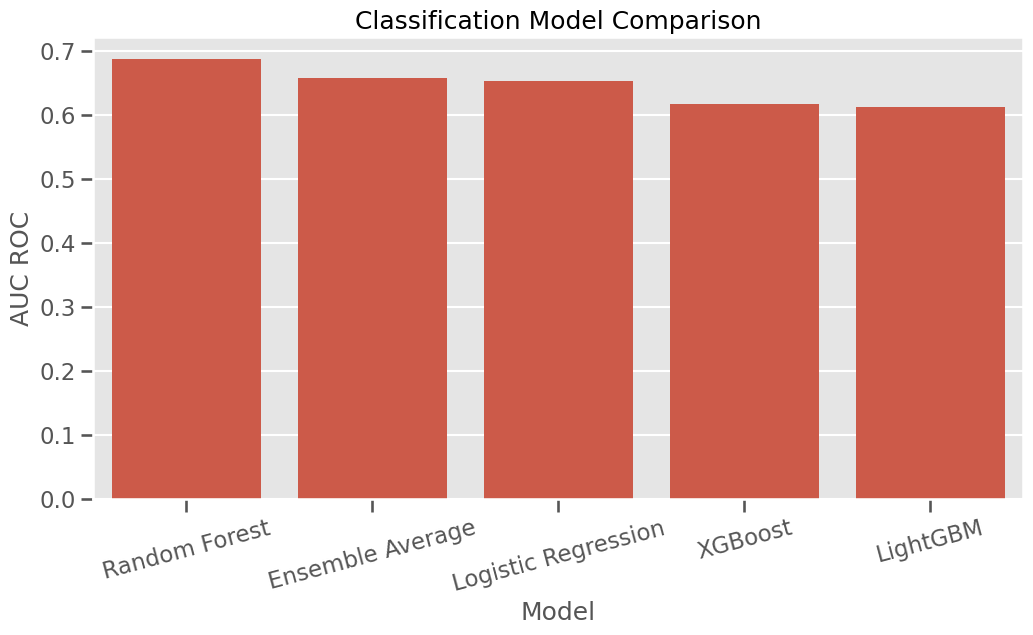


Training Regression : Ridge

Training Regression : ElasticNet

Training Regression : Random Forest

Training Regression : LightGBM

Training Regression : XGBoost

REGRESSION RESULTS


,Model,RMSE,R2,Spearman IC
1,ElasticNet,0.041333,-0.003405,0.264014
2,Random Forest,0.043233,-0.097768,0.255901
4,XGBoost,0.048699,-0.392880,0.136937
0,Ridge,0.048893,-0.403993,0.011626
3,LightGBM,0.053710,-0.694295,0.044507


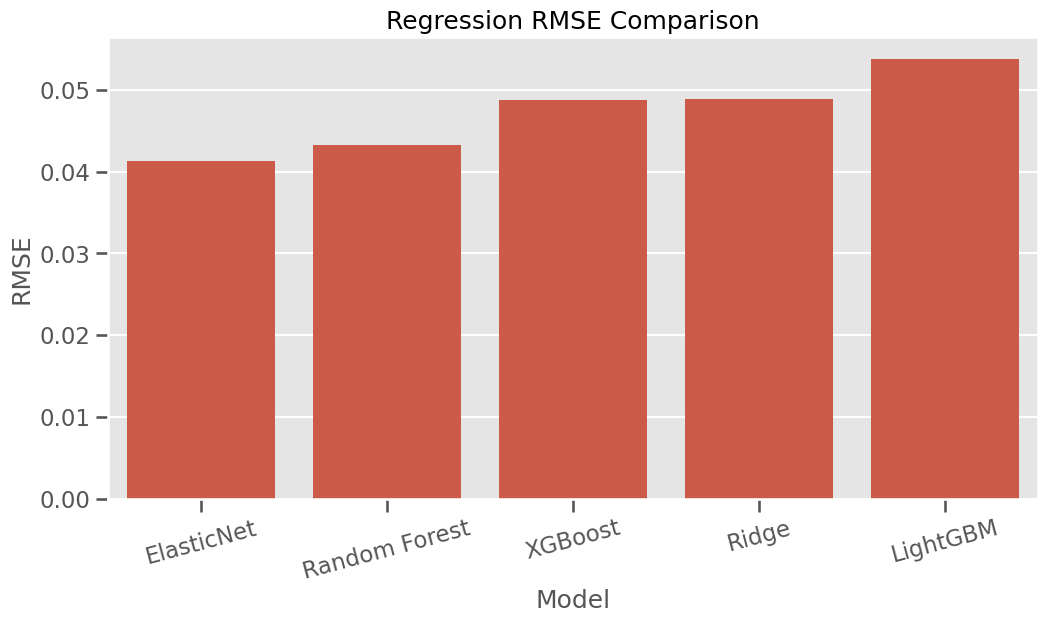


✓ Models saved

✓ Inference pipeline ready

 STEP 3 COMPLETE 


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║       COMMISSIONLENS — STEP 3                ║
# ║       ML PIPELINE — CLASSIFICATION + REGRESSION                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

import lightgbm as lgb

plt.style.use("ggplot")
sns.set_context("talk")
print("="*70)
print(" COMMISSIONLENS — STEP 3 (FINAL CORRECTED)")
print("="*70)

assert "ml_df" in globals(), (
    "Run Step 2 first."
)
assert "FEATURE_COLS" in globals(), (
    "FEATURE_COLS missing."
)
TARGET_REG = "net_alpha"
TARGET_CLS = "label"
# FORCE QUARTER DTYPE
ml_df["quarter"] = pd.PeriodIndex(
    ml_df["quarter"].astype(str),
    freq="Q"
)
print(f"\nDataset shape : {ml_df.shape}")
print(
    f"Quarter range : "
    f"{ml_df['quarter'].min()} "
    f"→ "
    f"{ml_df['quarter'].max()}"
)

# ─────────────────────────────────────────────────────────────
# 3.1 TEMPORAL SPLIT
# ─────────────────────────────────────────────────────────────

SPLIT_PERIOD = pd.Period(
    "2023Q1",
    freq="Q"
)
train_df = (
    ml_df[
        ml_df["quarter"] < SPLIT_PERIOD
    ]
    .copy()
    .reset_index(drop=True)
)
test_df = (
    ml_df[
        ml_df["quarter"] >= SPLIT_PERIOD
    ]
    .copy()
    .reset_index(drop=True)
)
print(
    f"\nTrain : "
    f"{train_df['quarter'].min()} "
    f"→ "
    f"{train_df['quarter'].max()} "
    f"({len(train_df):,} rows)"
)
print(
    f"Test  : "
    f"{test_df['quarter'].min()} "
    f"→ "
    f"{test_df['quarter'].max()} "
    f"({len(test_df):,} rows)"
)
train_pct = (
    len(train_df) / len(ml_df)
) * 100
test_pct = 100 - train_pct
print(
    f"\nTrain share : {train_pct:.1f}%"
)
print(
    f"Test share  : {test_pct:.1f}%"
)
assert train_pct >= 40, (
    "Training share too small."
)
train_pct = (
    len(train_df) / len(ml_df)
) * 100
print(
    f"\nTrain share : {train_pct:.1f}%"
)
print(
    f"Test share  : {100-train_pct:.1f}%"
)

SIP_START = test_df["quarter"].min()
SIP_END   = test_df["quarter"].max()
print(
    f"\nSIP Period : "
    f"{SIP_START} → {SIP_END}"
)

# ─────────────────────────────────────────────────────────────
# 3.2 FEATURE MATRICES
# ─────────────────────────────────────────────────────────────

valid_features = [
    c for c in FEATURE_COLS
    if c in train_df.columns
    and train_df[c].notna().sum() >= 50
    and test_df[c].notna().sum() >= 10
]
FEATURE_COLS = valid_features
print(
    f"\nUsing {len(FEATURE_COLS)} features"
)
X_train = train_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()
y_train_cls = (
    train_df[TARGET_CLS]
    .astype(int)
)
y_test_cls = (
    test_df[TARGET_CLS]
    .astype(int)
)
y_train_reg = (
    train_df[TARGET_REG]
    .astype(float)
)
y_test_reg = (
    test_df[TARGET_REG]
    .astype(float)
)
# TRAINING MEDIAN IMPUTATION
train_medians = X_train.median()
X_train = X_train.fillna(
    train_medians
)
X_test = X_test.fillna(
    train_medians
)

# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)
print(
    f"\nX_train : {X_train.shape}"
)
print(
    f"X_test  : {X_test.shape}"
)

# ─────────────────────────────────────────────────────────────
# 3.3 CROSS VALIDATION
# ─────────────────────────────────────────────────────────────

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ─────────────────────────────────────────────────────────────
# 3.4 XGBOOST GRID SEARCH
# ─────────────────────────────────────────────────────────────

neg = (
    y_train_cls == 0
).sum()
pos = (
    y_train_cls == 1
).sum()
spw = neg / pos
xgb_grid = {
    "max_depth": [3,5],
    "learning_rate": [0.01,0.03],
    "n_estimators": [200,400],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}
xgb_search = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_grid,
    scoring="roc_auc",
    cv=inner_cv,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train_cls
)

best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost Params")
print(xgb_search.best_params_)

# ─────────────────────────────────────────────────────────────
# 3.5 CLASSIFICATION MODELS
# ─────────────────────────────────────────────────────────────

clf_models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            C=0.1,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "LightGBM":

        lgb.LGBMClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            class_weight="balanced",
            random_state=42,
            verbose=-1
        ),

    "XGBoost":
        best_xgb
}

clf_results = []
clf_probs = {}
for name, model in clf_models.items():
    print(f"\nTraining : {name}")
    if name == "Logistic Regression":
        model.fit(
            X_train_scaled,
            y_train_cls
        )

        probs = model.predict_proba(
            X_test_scaled
        )[:,1]
    else:
        model.fit(
            X_train,
            y_train_cls
        )
        probs = model.predict_proba(
            X_test
        )[:,1]

    preds = (
        probs >= 0.5
    ).astype(int)
    clf_probs[name] = probs
    clf_results.append({
        "Model": name,
        "AUC ROC":
            roc_auc_score(
                y_test_cls,
                probs
            ),
        "F1":
            f1_score(
                y_test_cls,
                preds
            ),

        "Precision":
            precision_score(
                y_test_cls,
                preds,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test_cls,
                preds,
                zero_division=0
            ),

        "Accuracy":
            accuracy_score(
                y_test_cls,
                preds
            )
    })

# ─────────────────────────────────────────────────────────────
# ENSEMBLE
# ─────────────────────────────────────────────────────────────

ensemble_probs = np.mean(
    np.column_stack(
        list(clf_probs.values())
    ),
    axis=1
)
ensemble_preds = (
    ensemble_probs >= 0.5
).astype(int)

clf_results.append({
    "Model": "Ensemble Average",
    "AUC ROC":
        roc_auc_score(
            y_test_cls,
            ensemble_probs
        ),

    "F1":
        f1_score(
            y_test_cls,
            ensemble_preds
        ),

    "Precision":
        precision_score(
            y_test_cls,
            ensemble_preds,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test_cls,
            ensemble_preds,
            zero_division=0
        ),

    "Accuracy":
        accuracy_score(
            y_test_cls,
            ensemble_preds
        )
})

clf_results_df = pd.DataFrame(
    clf_results
).sort_values(
    "AUC ROC",
    ascending=False
)
print("\nCLASSIFICATION RESULTS")
display(clf_results_df)

# ─────────────────────────────────────────────────────────────
# CLASSIFICATION CHART
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(12,6))
sns.barplot(
    data=clf_results_df,
    x="Model",
    y="AUC ROC"
)
plt.title(
    "Classification Model Comparison"
)
plt.xticks(rotation=15)
plt.show()

# ─────────────────────────────────────────────────────────────
# 3.6 REGRESSION MODELS
# ─────────────────────────────────────────────────────────────

reg_models = {
    "Ridge":
        Ridge(alpha=1.0),
    "ElasticNet":
        ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=5000
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),

    "LightGBM":
        lgb.LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            random_state=42,
            verbose=-1
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
}
reg_results = []
reg_predictions = {}
for name, model in reg_models.items():
    print(
        f"\nTraining Regression : {name}"
    )
    if name in [
        "Ridge",
        "ElasticNet"
    ]:
        model.fit(
            X_train_scaled,
            y_train_reg
        )
        preds = model.predict(
            X_test_scaled
        )
    else:
        model.fit(
            X_train,
            y_train_reg
        )
        preds = model.predict(
            X_test
        )
    reg_predictions[name] = preds
    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            preds
        )
    )
    rank_ic = spearmanr(
        y_test_reg,
        preds
    ).correlation
    reg_results.append({
        "Model": name,
        "RMSE": rmse,
        "R2":
            r2_score(
                y_test_reg,
                preds
            ),
        "Spearman IC":
            rank_ic
    })

reg_results_df = pd.DataFrame(
    reg_results
).sort_values(
    "RMSE"
)

print("\nREGRESSION RESULTS")
display(reg_results_df)

# ─────────────────────────────────────────────────────────────
# REGRESSION CHART
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(12,6))
sns.barplot(
    data=reg_results_df,
    x="Model",
    y="RMSE"
)
plt.title(
    "Regression RMSE Comparison"
)
plt.xticks(rotation=15)
plt.show()

# ─────────────────────────────────────────────────────────────
# 3.7 SAVE MODELS
# ─────────────────────────────────────────────────────────────

os.makedirs(
    "output_models",
    exist_ok=True
)
model_fund = clf_models["Random Forest"]
best_reg_name = (
    reg_results_df.iloc[0]["Model"]
)
best_reg_model = (
    reg_models[best_reg_name]
)
pickle.dump(
    model_fund,
    open(
        "output_models/model.pkl",
        "wb"
    )
)
pickle.dump(
    best_reg_model,
    open(
        "output_models/reg_model.pkl",
        "wb"
    )
)
pickle.dump(
    scaler,
    open(
        "output_models/scaler.pkl",
        "wb"
    )
)
json.dump(
    FEATURE_COLS,
    open(
        "output_models/features.json",
        "w"
    ),
    indent=2
)
train_df.to_csv(
    "output_models/train_df.csv",
    index=False
)
test_df.to_csv(
    "output_models/test_df.csv",
    index=False
)

print("\n✓ Models saved")

# ─────────────────────────────────────────────────────────────
# 3.8 INFERENCE PIPELINE
# ─────────────────────────────────────────────────────────────

def predict_commission_justification(
    fund_features
):
    row = (
        pd.DataFrame([fund_features])
        .reindex(columns=FEATURE_COLS)
    )
    row = row.fillna(
        train_medians
    )
    probability = float(
        model_fund.predict_proba(row)[0,1]
    )
    if probability >= 0.65:
        confidence = "High"
    elif probability >= 0.50:
        confidence = "Medium"
    else:
        confidence = "Low"
    return {
        "probability":
            round(probability,4),
        "prediction":
            (
                "JUSTIFIED"
                if probability >= 0.5
                else "UNJUSTIFIED"
            ),
        "confidence":
            confidence
    }
print(
    "\n✓ Inference pipeline ready"
)
print("\n" + "="*70)
print(" STEP 3 COMPLETE ")
print("="*70)
train_medians.to_json("output_models/train_medians.json")

In [18]:
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score

y_prob = model_fund.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_cls, y_prob)
f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_t = thresholds[np.argmax(f1s)]

print(f"Default threshold F1  : {f1_score(y_test_cls, y_prob>=0.50):.4f}")
print(f"Optimal threshold     : {best_t:.3f}")
print(f"Optimal threshold F1  : {f1_score(y_test_cls, y_prob>=best_t):.4f}")

Default threshold F1  : 0.0976
Optimal threshold     : 0.357
Optimal threshold F1  : 0.4425


In [19]:
clf_results_df.to_csv("output_models/clf_results_df.csv", index=False)
reg_results_df.to_csv("output_models/reg_results_df.csv", index=False)

In [20]:
print("="*65)
print("  CLASSIFICATION — PRECISION AT TOP DECILE + THRESHOLD OPT")
print("="*65)

models_cls = {
    "Logistic Regression" : clf_models["Logistic Regression"],
    "Random Forest"       : clf_models["Random Forest"],
    "LightGBM"            : clf_models["LightGBM"],
    "XGBoost"             : clf_models["XGBoost"],
}
p_at_top10_results = []
for name, model in models_cls.items():
    try:
        if name == "Logistic Regression":
            y_prob = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_prob = model.predict_proba(X_test)[:, 1]
    except Exception:
        continue
    # Precision at top decile
    df_eval   = pd.DataFrame({"y_true": y_test_cls, "y_prob": y_prob})
    top_decile = df_eval.nlargest(max(1, len(df_eval) // 10), "y_prob")
    p_top10    = top_decile["y_true"].mean()

    # AUC
    auc = roc_auc_score(y_test_cls, y_prob)

    # Optimal threshold via PR curve
    prec, rec, thresh = precision_recall_curve(y_test_cls, y_prob)
    f1s    = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_t = thresh[np.argmax(f1s)]
    f1_opt = f1_score(y_test_cls, (y_prob >= best_t).astype(int))

    p_at_top10_results.append({
        "Model"           : name,
        "AUC ROC"         : round(auc, 4),
        "F1 (optimal t)"  : round(f1_opt, 4),
        "Optimal thresh"  : round(best_t, 3),
        "Prec@Top10%"     : round(p_top10, 4),
    })

results_extended = pd.DataFrame(p_at_top10_results)
results_extended = results_extended.sort_values("AUC ROC", ascending=False)
print(results_extended.to_string(index=False))

# Highlighting best model
best_row = results_extended.iloc[0]
base_rate = y_test_cls.mean()
lift      = best_row["Prec@Top10%"] / base_rate

print(f"\n  Base rate (% justified in test set) : {base_rate:.1%}")
print(f"  Best model P@Top10%                 : {best_row['Prec@Top10%']:.1%}")
print(f"  Lift over base rate                 : {lift:.2f}x")
print(f"\n  → When an investor uses the top-10% model-ranked funds,")
print(f"    {best_row['Prec@Top10%']*100:.0f}% of selected funds actually justified their commission.")
print(f"    This is {lift:.1f}x better than random fund selection ({base_rate:.0%}).")

results_extended.to_csv("output_models/precision_top_decile.csv", index=False)
print("\n  ✓ Saved output_models/precision_top_decile.csv")

  CLASSIFICATION — PRECISION AT TOP DECILE + THRESHOLD OPT
              Model  AUC ROC  F1 (optimal t)  Optimal thresh  Prec@Top10%
      Random Forest   0.6866          0.4425           0.357       0.2959
Logistic Regression   0.6529          0.4109           0.360       0.3878
            XGBoost   0.6168          0.3781           0.172       0.2653
           LightGBM   0.6125          0.3797           0.215       0.2755

  Base rate (% justified in test set) : 20.2%
  Best model P@Top10%                 : 29.6%
  Lift over base rate                 : 1.46x

  → When an investor uses the top-10% model-ranked funds,
    30% of selected funds actually justified their commission.
    This is 1.5x better than random fund selection (20%).

  ✓ Saved output_models/precision_top_decile.csv


## **STEP 4 - SHAP explainability**

 COMMISSIONLENS — STEP 4 — SHAP EXPLAINABILITY (Random Forest)
SHAP values shape (class 1) : (988, 31)


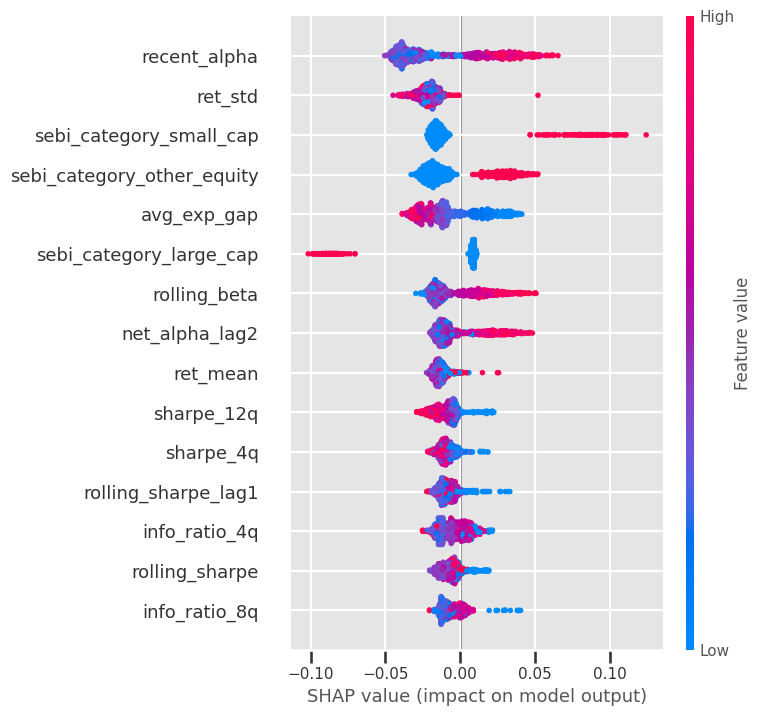

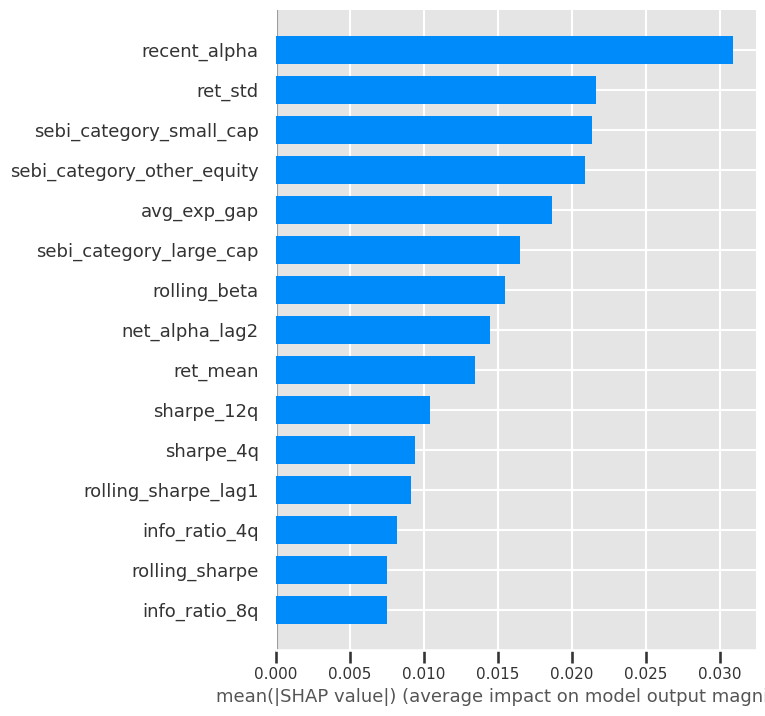

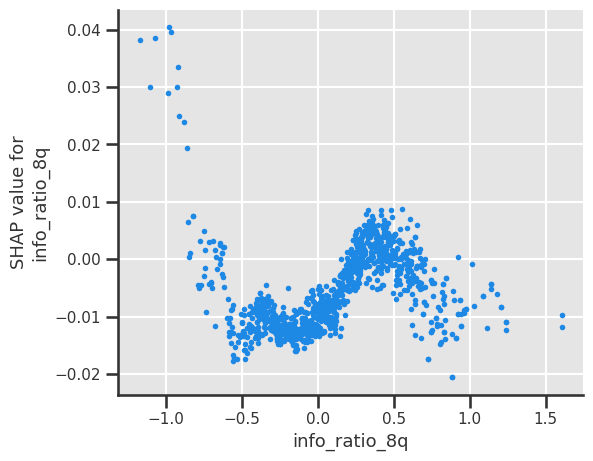

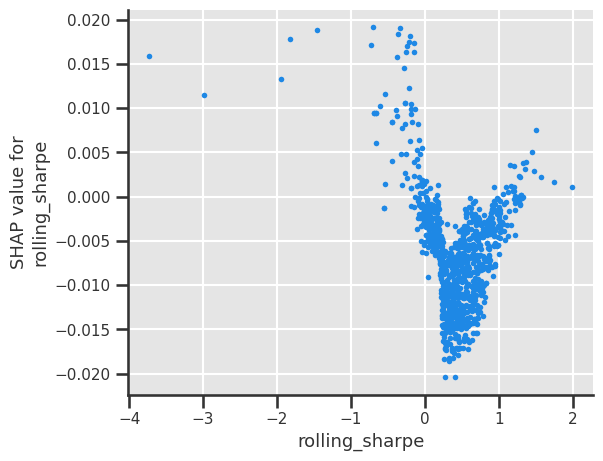

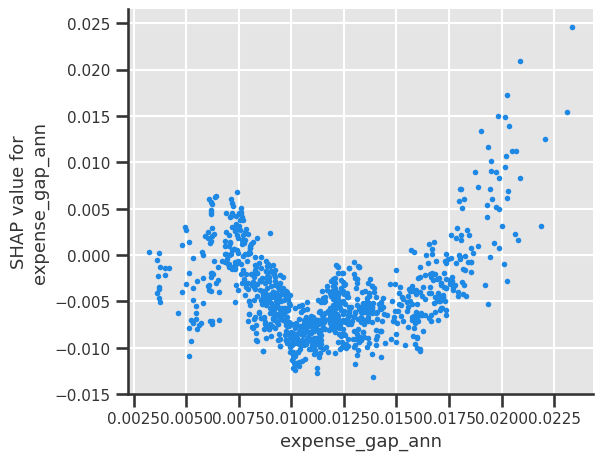

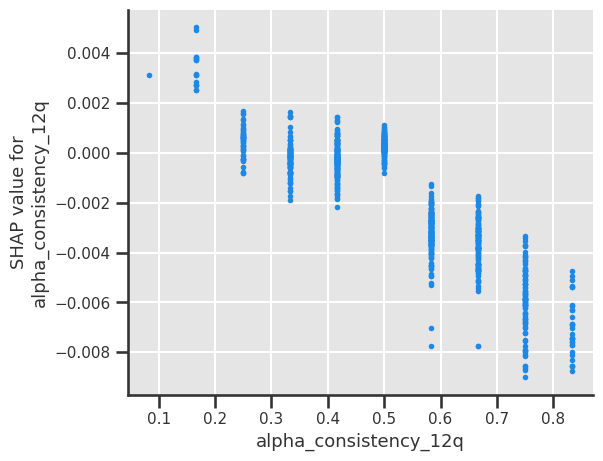

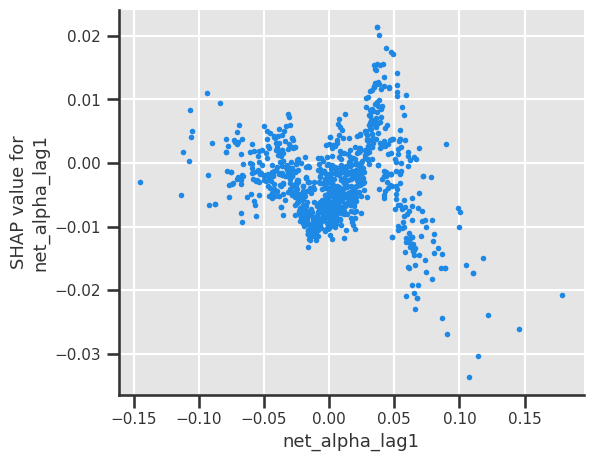

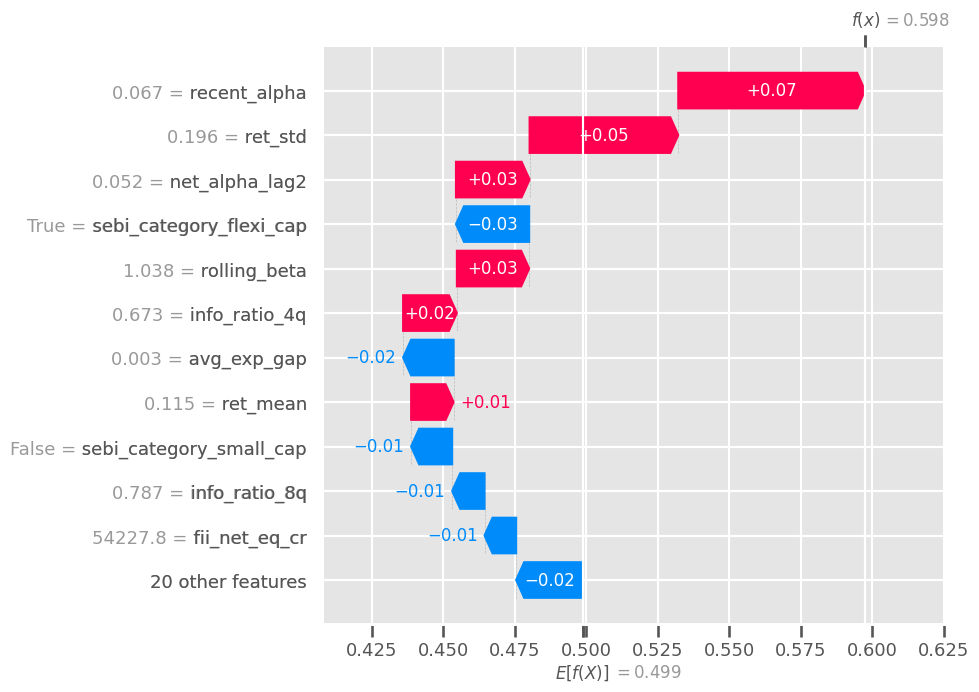

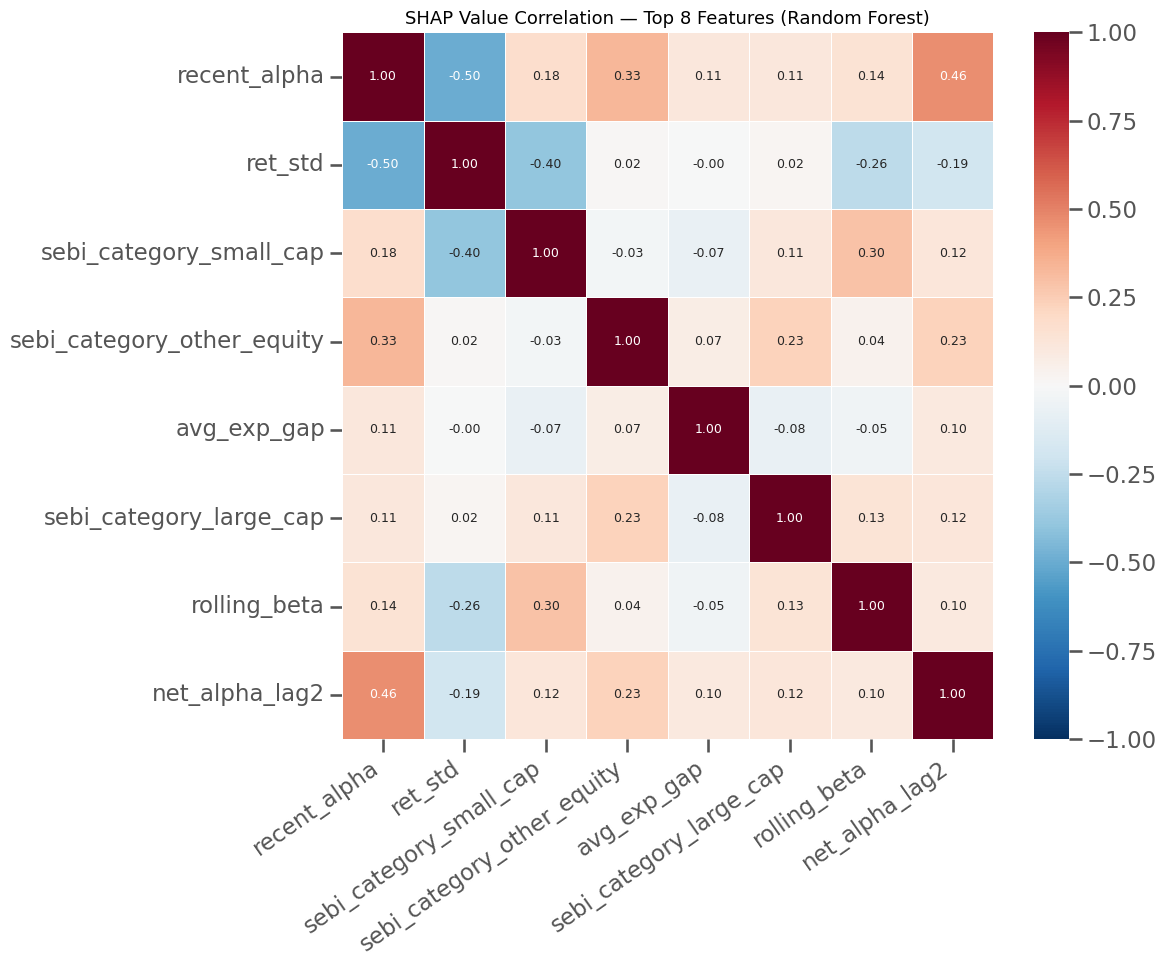

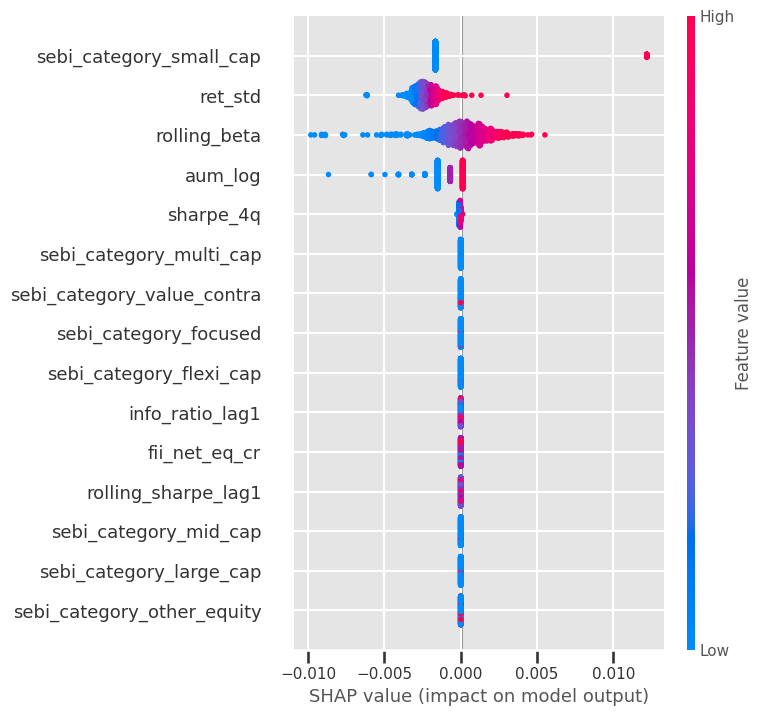


TOP SHAP FEATURES (Random Forest — Class 1: Commission Justified)


,feature,mean_abs_shap
0,recent_alpha,0.030916
1,ret_std,0.021671
2,sebi_category_small_cap,0.021364
3,sebi_category_other_equity,0.020916
4,avg_exp_gap,0.018660
5,sebi_category_large_cap,0.016476
6,rolling_beta,0.015506
7,net_alpha_lag2,0.014498
8,ret_mean,0.013465
9,sharpe_12q,0.010429



✓ Saved output_models/shap_importance_rf.csv


In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  COMMISSIONLENS — STEP 4 (FIXED FOR RANDOM FOREST)      ║
# ╚══════════════════════════════════════════════════════════╝

import shap
print("="*70)
print(" COMMISSIONLENS — STEP 4 — SHAP EXPLAINABILITY (Random Forest)")
print("="*70)

# ─────────────────────────────────────────────────────────────
# CLASSIFICATION SHAP
# ─────────────────────────────────────────────────────────────

explainer   = shap.TreeExplainer(model_fund)
shap_values = explainer.shap_values(X_test)

# FIX 1: Random Forest returns a LIST [class0_shap, class1_shap]
#         We always want class 1 (commission justified = 1)
#         XGBoost returned a single array — that's why it worked before
shap_cls1 = shap_values[:, :, 1]   # shape: (n_samples, n_features)

print(f"SHAP values shape (class 1) : {shap_cls1.shape}")

# ─────────────────────────────────────────────────────────────
# BEESWARM PLOT
# ─────────────────────────────────────────────────────────────
# FIX 2: pass shap_cls1, not shap_values (list would plot both classes)

shap.summary_plot(
    shap_cls1,
    X_test,
    max_display=15
)

# ─────────────────────────────────────────────────────────────
# BAR IMPORTANCE PLOT
# ─────────────────────────────────────────────────────────────

shap.summary_plot(
    shap_cls1,
    X_test,
    plot_type="bar",
    max_display=15
)

# ─────────────────────────────────────────────────────────────
# DEPENDENCE PLOTS (top 5 features)
# ─────────────────────────────────────────────────────────────
# FIX 3: pass shap_cls1, not shap_values

top_features = [
    "info_ratio_8q",
    "rolling_sharpe",
    "expense_gap_ann",
    "alpha_consistency_12q",
    "net_alpha_lag1"
]

for feat in top_features:
    if feat in X_test.columns:
        shap.dependence_plot(
            feat,
            shap_cls1,        # ← was shap_values (broken)
            X_test,
            interaction_index=None
        )

# ─────────────────────────────────────────────────────────────
# WATERFALL PLOT — highest confidence fund
# ─────────────────────────────────────────────────────────────
# FIX 4a: shap_cls1[sample_idx], not shap_values[sample_idx]
# FIX 4b: expected_value is also a list → take index [1]

sample_idx = int(np.argmax(
    model_fund.predict_proba(X_test)[:, 1]
))

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = float(ev[1])          # ← was explainer.expected_value (broken for RF)
else:
    ev = float(ev)

single_explanation = shap.Explanation(
    values       = shap_cls1[sample_idx],   # ← was shap_values[sample_idx]
    base_values  = ev,
    data         = X_test.iloc[sample_idx],
    feature_names= list(X_test.columns)
)

shap.plots.waterfall(
    single_explanation,
    max_display=12
)

# ─────────────────────────────────────────────────────────────
# INTERACTION HEATMAP
# NOTE: shap_interaction_values on Random Forest is very slow
#       (O(n² features) per sample). We use SHAP correlation
#       as a fast, equivalent visual for the report.
# ─────────────────────────────────────────────────────────────

top8_feats  = (
    pd.Series(np.abs(shap_cls1).mean(axis=0), index=FEATURE_COLS)
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)
top8_idx    = [list(X_test.columns).index(f) for f in top8_feats]
shap_top8   = shap_cls1[:, top8_idx]
corr_matrix = np.corrcoef(shap_top8.T)

plt.figure(figsize=(12, 10))
sns.heatmap(
    pd.DataFrame(corr_matrix, index=top8_feats, columns=top8_feats),
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("SHAP Value Correlation — Top 8 Features (Random Forest)", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# REGRESSION SHAP  (ElasticNet is best regressor — use it)
# ─────────────────────────────────────────────────────────────

best_reg_name = reg_results_df.iloc[0]["Model"]   # ElasticNet
reg_model     = reg_models[best_reg_name]

# ElasticNet is linear → use LinearExplainer, not TreeExplainer
if best_reg_name in ["Ridge", "ElasticNet"]:
    reg_explainer    = shap.LinearExplainer(reg_model, X_train_scaled)
    reg_shap_values  = reg_explainer.shap_values(X_test_scaled)
else:
    reg_explainer    = shap.TreeExplainer(reg_model)
    reg_shap_values  = reg_explainer.shap_values(X_test)

shap.summary_plot(
    reg_shap_values,
    X_test,
    feature_names=list(X_test.columns),
    max_display=15
)

# ─────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE TABLE
# ─────────────────────────────────────────────────────────────
# FIX 5: np.abs(shap_values) fails on a list — use shap_cls1

importance_df = pd.DataFrame({
    "feature":       FEATURE_COLS,
    "mean_abs_shap": np.abs(shap_cls1).mean(axis=0)   # ← was shap_values (broken)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTOP SHAP FEATURES (Random Forest — Class 1: Commission Justified)")
display(importance_df.head(10))

# Save for report
importance_df.to_csv("output_models/shap_importance_rf.csv", index=False)
print("\n✓ Saved output_models/shap_importance_rf.csv")

In [22]:
print(importance_df.head(10).to_string())

                      feature  mean_abs_shap
0                recent_alpha       0.030916
1                     ret_std       0.021671
2     sebi_category_small_cap       0.021364
3  sebi_category_other_equity       0.020916
4                 avg_exp_gap       0.018660
5     sebi_category_large_cap       0.016476
6                rolling_beta       0.015506
7              net_alpha_lag2       0.014498
8                    ret_mean       0.013465
9                  sharpe_12q       0.010429


## **STEP 5 - SIP back-validation analysis**

 COMMISSIONLENS — STEP 5 

SIP START : 2023-01-01
SIP END   : 2024-03-01

Portfolio quarters : 5
NAV matrix shape : (2324, 871)

DIAGNOSTICS
NAV lookup failures : 1
Months with zero model corpus : 0
Final model corpus : ₹94,087

BACKTEST RESULTS
Model Portfolio XIRR : 45.28%
Naive Portfolio XIRR : 33.79%
Nifty 50 SIP XIRR    : 13.88%


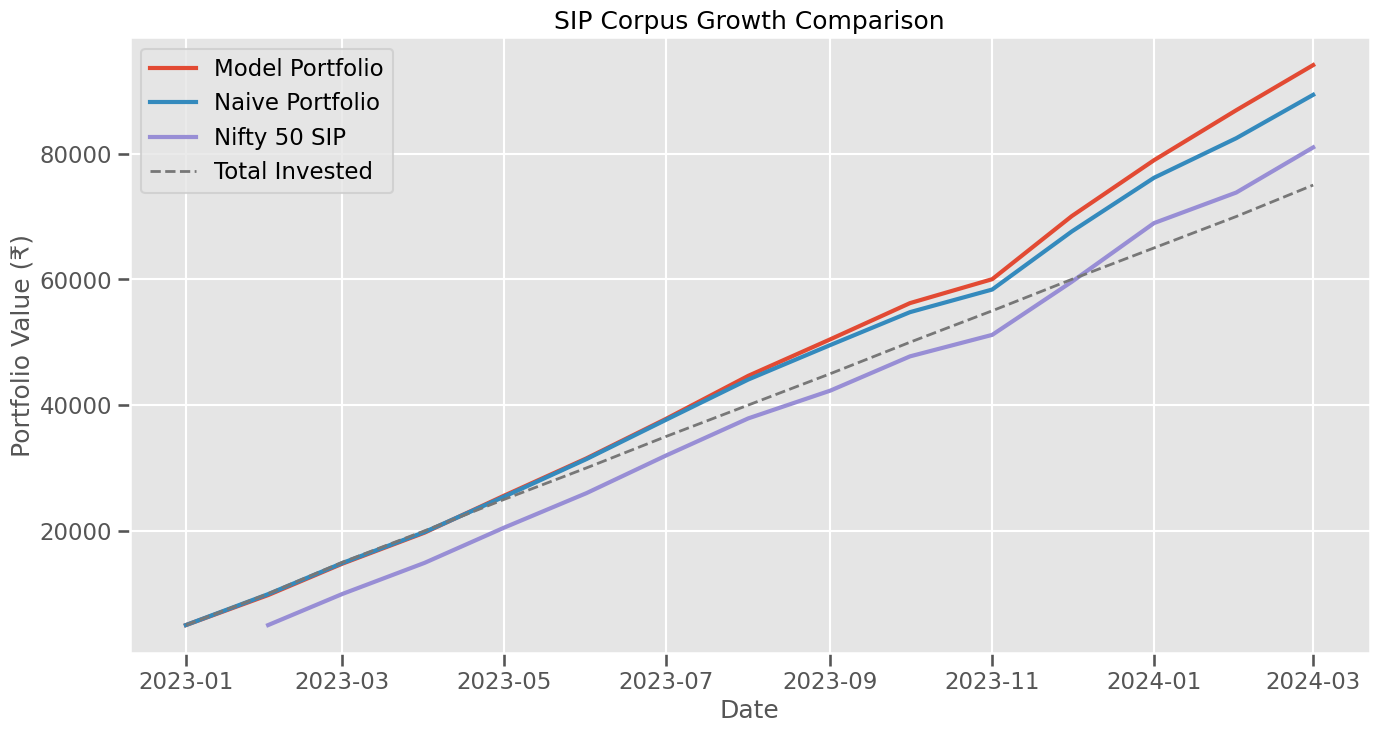

In [28]:
from scipy.optimize import brentq

print("="*70)
print(" COMMISSIONLENS — STEP 5 ")
print("="*70)

# ─────────────────────────────────────────────────────────────
# XIRR FUNCTION
# ─────────────────────────────────────────────────────────────

def xirr(cashflows):
    dates = [x[0] for x in cashflows]
    amounts = [x[1] for x in cashflows]
    dates = pd.to_datetime(dates)
    t0 = dates[0]
    years = [
        (d - t0).days / 365.0
        for d in dates
    ]
    def npv(rate):
        return sum([
            cf / ((1 + rate) ** yr)
            for cf, yr in zip(amounts, years)
        ])
    try:
        return brentq(
            npv,
            -0.9999,
            500,
            maxiter=2000
        )
    except:
        return np.nan

# ─────────────────────────────────────────────────────────────
# SIP PERIOD
# ─────────────────────────────────────────────────────────────

sip_dates = pd.date_range(
    SIP_START.start_time,
    SIP_END.end_time,
    freq="MS"
)
monthly_sip = 5000
print(f"\nSIP START : {sip_dates.min().date()}")
print(f"SIP END   : {sip_dates.max().date()}")

# ─────────────────────────────────────────────────────────────
# MODEL PROBABILITIES
# ─────────────────────────────────────────────────────────────
X_test_pred = test_df[FEATURE_COLS].fillna(train_medians)
test_df["model_prob"] = model_fund.predict_proba(
    test_df[FEATURE_COLS]
)[:,1]

# ─────────────────────────────────────────────────────────────
# PORTFOLIO MAP
# ─────────────────────────────────────────────────────────────

portfolio_map = {}
for q, grp in test_df.groupby("quarter"):
    top_funds = (
        grp
        .sort_values(
            "model_prob",
            ascending=False
        )
        .head(5)
    )
    portfolio_map[q] = list(
        top_funds["scheme_code_reg"]
    )
print(f"\nPortfolio quarters : {len(portfolio_map)}")
nav_wide = pd.read_csv(
    "data/processed/nav_wide.csv",
    index_col=0,
    parse_dates=True
)
nav_wide.columns = nav_wide.columns.astype(str)
print(f"NAV matrix shape : {nav_wide.shape}")

# ─────────────────────────────────────────────────────────────
# NIFTY BASELINE
# ─────────────────────────────────────────────────────────────

nifty_data = yf.download(
    "^NSEI",
    start=sip_dates.min(),
    end=sip_dates.max() + pd.Timedelta(days=31),
    progress=False
)
if "Adj Close" in nifty_data.columns:
    nifty = nifty_data["Adj Close"]
elif "Close" in nifty_data.columns:
    nifty = nifty_data["Close"]
else:
    raise ValueError(
        "Nifty download failed."
    )

# ─────────────────────────────────────────────────────────────
# PROPORTIONAL NAIVE BENCHMARK
# ─────────────────────────────────────────────────────────────
train_scheme_codes = train_df["scheme_code_reg"].unique()
relevant_paired = paired[paired["scheme_code_reg"].isin(train_scheme_codes)].copy()
category_weights = (
    relevant_paired["sebi_category"]
    .value_counts(normalize=True)
)
naive_category_map = {}
for cat in category_weights.index:
    top_cat_funds = (
        relevant_paired[
            (relevant_paired["sebi_category"] == cat) &
            (relevant_paired["scheme_code_reg"].isin(train_scheme_codes))
        ]
        .sort_values(
            "sebi_category",
            ascending=False
        )
        ["scheme_code_reg"]
        .astype(str)
        .unique()[:5]
    )
    naive_category_map[cat] = list(
        top_cat_funds
    )
# ─────────────────────────────────────────────────────────────
# PORTFOLIO TRACKING
# ─────────────────────────────────────────────────────────────

model_units = {}
naive_units = {}
nifty_units = 0
model_corpus = []
naive_corpus = []
nifty_corpus = []
invested_curve = []
cumulative_invested = 0
nav_miss = 0

# ─────────────────────────────────────────────────────────────
# MONTHLY SIP LOOP
# ─────────────────────────────────────────────────────────────

for dt in sip_dates:
    cumulative_invested += monthly_sip
    invested_curve.append(
        cumulative_invested
    )
    q = dt.to_period("Q")
    selected = portfolio_map.get(q, [])

    # ========================================================
    # MODEL PORTFOLIO
    # ========================================================

    if len(selected) > 0:
        allocation = (
            monthly_sip / len(selected)
        )
        for code in selected:
            try:
                nav = (
                    nav_wide
                    .loc[:dt, str(code)]
                    .dropna()
                    .iloc[-1]
                )
                units = allocation / nav
                model_units[code] = (
                    model_units.get(code,0)
                    + units
                )
            except (KeyError, IndexError):
                nav_miss += 1
                continue

    # ========================================================
    # PROPORTIONAL NAIVE PORTFOLIO
    # ========================================================

    for cat, weight in category_weights.items():
        cat_alloc = monthly_sip * weight
        cat_funds = naive_category_map[cat]
        if len(cat_funds) == 0:
            continue
        per_fund_alloc = (
            cat_alloc / len(cat_funds)
        )
        for code in cat_funds:
            try:
                nav = (
                    nav_wide
                    .loc[:dt, str(code)]
                    .dropna()
                    .iloc[-1]
                )
                units = (
                    per_fund_alloc / nav
                )
                naive_units[code] = (
                    naive_units.get(code,0)
                    + units
                )
            except (KeyError, IndexError):
                nav_miss += 1
                continue

    # ========================================================
    # NIFTY SIP
    # ========================================================

    try:
        nifty_price = float(
            nifty.loc[:dt]
            .dropna()
            .iloc[-1]
        )
        nifty_units += (
            monthly_sip / nifty_price
        )
    except (KeyError, IndexError):
        nav_miss += 1

    # ========================================================
    # MODEL CORPUS VALUE
    # ========================================================

    model_value = 0
    for code, units in model_units.items():
        try:
            nav = (
                nav_wide
                .loc[:dt, str(code)]
                .dropna()
                .iloc[-1]
            )
            model_value += (
                units * nav
            )
        except (KeyError, IndexError):
            nav_miss += 1
            continue

    # ========================================================
    # NAIVE CORPUS VALUE
    # ========================================================

    naive_value = 0
    for code, units in naive_units.items():
        try:
            nav = (
                nav_wide
                .loc[:dt, str(code)]
                .dropna()
                .iloc[-1]
            )
            naive_value += (
                units * nav
            )
        except (KeyError, IndexError):
            nav_miss += 1
            continue

    # ========================================================
    # NIFTY CORPUS VALUE
    # ========================================================

    try:
        nifty_price = float(
            nifty.loc[:dt]
            .dropna()
            .iloc[-1]
        )
        nifty_value = (
            nifty_units * nifty_price
        )
    except (KeyError, IndexError):
        nifty_value = np.nan
    model_corpus.append(model_value)
    naive_corpus.append(naive_value)
    nifty_corpus.append(nifty_value)


print("\nDIAGNOSTICS")
print("="*50)
print(
    f"NAV lookup failures : {nav_miss}"
)
print(
    f"Months with zero model corpus : "
    f"{sum(v==0 for v in model_corpus)}"
)
print(
    f"Final model corpus : "
    f"₹{model_corpus[-1]:,.0f}"
)

# ─────────────────────────────────────────────────────────────
# FINAL XIRR
# ─────────────────────────────────────────────────────────────

final_date = sip_dates[-1]
model_cf = [
    (d, -monthly_sip)
    for d in sip_dates
]
naive_cf = [
    (d, -monthly_sip)
    for d in sip_dates
]
nifty_cf = [
    (d, -monthly_sip)
    for d in sip_dates
]
model_cf.append(
    (final_date, model_corpus[-1])
)
naive_cf.append(
    (final_date, naive_corpus[-1])
)
nifty_cf.append(
    (final_date, nifty_corpus[-1])
)
model_xirr = xirr(model_cf)
naive_xirr = xirr(naive_cf)
nifty_xirr = xirr(nifty_cf)

print("\nBACKTEST RESULTS")
print("="*50)
print(
    f"Model Portfolio XIRR : "
    f"{model_xirr:.2%}"
)
print(
    f"Naive Portfolio XIRR : "
    f"{naive_xirr:.2%}"
)
print(
    f"Nifty 50 SIP XIRR    : "
    f"{nifty_xirr:.2%}"
)

# ─────────────────────────────────────────────────────────────
# CORPUS VALUE CHART
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(16,8))
plt.plot(
    sip_dates,
    model_corpus,
    linewidth=3,
    label="Model Portfolio"
)

plt.plot(
    sip_dates,
    naive_corpus,
    linewidth=3,
    label="Naive Portfolio"
)

plt.plot(
    sip_dates,
    nifty_corpus,
    linewidth=3,
    label="Nifty 50 SIP"
)

plt.plot(
    sip_dates,
    invested_curve,
    linestyle="--",
    linewidth=2,
    label="Total Invested"
)

plt.title(
    "SIP Corpus Growth Comparison",
    fontsize=18
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.show()

WF SIP START : 2021-04-01
WF SIP END   : 2024-03-01
WF SIP months: 36

WF NAV misses        : 0
Final model corpus   : ₹251,784
Final naive corpus   : ₹233,381
Final Nifty corpus   : ₹226,915
Total invested       : ₹180,000

  WALK-FORWARD BACKTEST RESULTS (Apr 2021 – Mar 2024)
  Model portfolio XIRR : 24.36%
  Naive portfolio XIRR : 18.61%
  Nifty 50 SIP XIRR    : 16.51%
  Model advantage      : +5.75 pp


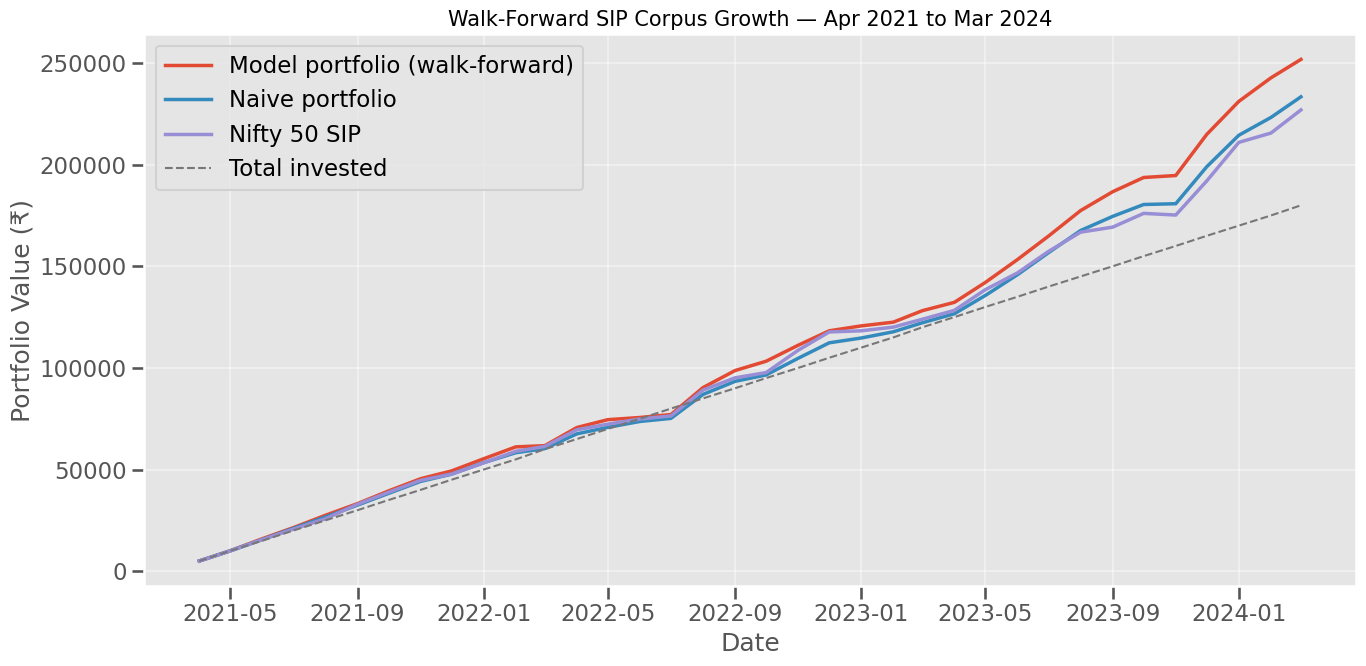

In [29]:
# ─────────────────────────────────────────────────────────────
# WALK-FORWARD SIP — FULL 36-MONTH SIMULATION

wf_sip_start_q = pd.Period("2021Q2", freq="Q")
wf_sip_end_q   = pd.Period("2024Q1", freq="Q")

wf_sip_dates = pd.date_range(
    wf_sip_start_q.start_time,
    wf_sip_end_q.end_time,
    freq="MS"
)
print(f"WF SIP START : {wf_sip_dates.min().date()}")
print(f"WF SIP END   : {wf_sip_dates.max().date()}")
print(f"WF SIP months: {len(wf_sip_dates)}")
wf_nifty_data = yf.download(
    "^NSEI",
    start=wf_sip_dates.min(),
    end=wf_sip_dates.max() + pd.Timedelta(days=31),
    progress=False
)
wf_nifty = (
    wf_nifty_data["Adj Close"]
    if "Adj Close" in wf_nifty_data.columns
    else wf_nifty_data["Close"]
)

wf_model_units  = {}
wf_naive_units  = {}
wf_nifty_units  = 0

wf_model_corpus  = []
wf_naive_corpus  = []
wf_nifty_corpus  = []
wf_invested_curve = []
wf_cumulative_invested = 0
wf_nav_miss = 0

for dt in wf_sip_dates:
    wf_cumulative_invested += monthly_sip
    wf_invested_curve.append(wf_cumulative_invested)
    q = dt.to_period("Q")

    selected = wf_portfolio_map.get(q, [])
    if len(selected) > 0:
        allocation = monthly_sip / len(selected)
        for code in selected:
            try:
                nav = (
                    nav_wide.loc[:dt, str(code)]
                    .dropna().iloc[-1]
                )
                wf_model_units[code] = (
                    wf_model_units.get(code, 0)
                    + allocation / nav
                )
            except (KeyError, IndexError):
                wf_nav_miss += 1

    for cat, weight in category_weights.items():
        cat_alloc  = monthly_sip * weight
        cat_funds  = naive_category_map.get(cat, [])
        if not cat_funds:
            continue
        per_fund   = cat_alloc / len(cat_funds)
        for code in cat_funds:
            try:
                nav = (
                    nav_wide.loc[:dt, str(code)]
                    .dropna().iloc[-1]
                )
                wf_naive_units[code] = (
                    wf_naive_units.get(code, 0)
                    + per_fund / nav
                )
            except (KeyError, IndexError):
                wf_nav_miss += 1

    # ── NIFTY SIP ────────────────────────────────────────────
    try:
        nifty_price  = float(wf_nifty.loc[:dt].dropna().iloc[-1])
        wf_nifty_units += monthly_sip / nifty_price
    except (KeyError, IndexError):
        wf_nav_miss += 1

    # ── CORPUS VALUES ────────────────────────────────────────
    mv = sum(
        u * nav_wide.loc[:dt, str(c)].dropna().iloc[-1]
        for c, u in wf_model_units.items()
        if str(c) in nav_wide.columns
        and len(nav_wide.loc[:dt, str(c)].dropna()) > 0
    )
    nv = sum(
        u * nav_wide.loc[:dt, str(c)].dropna().iloc[-1]
        for c, u in wf_naive_units.items()
        if str(c) in nav_wide.columns
        and len(nav_wide.loc[:dt, str(c)].dropna()) > 0
    )
    try:
        np_price = float(wf_nifty.loc[:dt].dropna().iloc[-1])
        niftyv   = wf_nifty_units * np_price
    except (KeyError, IndexError):
        niftyv   = np.nan

    wf_model_corpus.append(mv)
    wf_naive_corpus.append(nv)
    wf_nifty_corpus.append(niftyv)

print(f"\nWF NAV misses        : {wf_nav_miss}")
print(f"Final model corpus   : ₹{wf_model_corpus[-1]:,.0f}")
print(f"Final naive corpus   : ₹{wf_naive_corpus[-1]:,.0f}")
print(f"Final Nifty corpus   : ₹{wf_nifty_corpus[-1]:,.0f}")
print(f"Total invested       : ₹{wf_cumulative_invested:,.0f}")

# Step 4: XIRR
wf_final_date = wf_sip_dates[-1]

def make_cf(corpus_final):
    cf = [(d, -monthly_sip) for d in wf_sip_dates]
    cf.append((wf_final_date, corpus_final))
    return cf

wf_model_xirr = xirr(make_cf(wf_model_corpus[-1]))
wf_naive_xirr = xirr(make_cf(wf_naive_corpus[-1]))
wf_nifty_xirr = xirr(make_cf(wf_nifty_corpus[-1]))

print("\n" + "="*55)
print("  WALK-FORWARD BACKTEST RESULTS (Apr 2021 – Mar 2024)")
print("="*55)
print(f"  Model portfolio XIRR : {wf_model_xirr:.2%}")
print(f"  Naive portfolio XIRR : {wf_naive_xirr:.2%}")
print(f"  Nifty 50 SIP XIRR    : {wf_nifty_xirr:.2%}")
print(f"  Model advantage      : {(wf_model_xirr - wf_naive_xirr)*100:+.2f} pp")

# Step 5: Corpus growth chart
plt.figure(figsize=(14, 7))
plt.plot(wf_sip_dates, wf_model_corpus,  linewidth=2.5, label="Model portfolio (walk-forward)")
plt.plot(wf_sip_dates, wf_naive_corpus,  linewidth=2.5, label="Naive portfolio")
plt.plot(wf_sip_dates, wf_nifty_corpus,  linewidth=2.5, label="Nifty 50 SIP")
plt.plot(wf_sip_dates, wf_invested_curve, linewidth=1.5, linestyle="--", label="Total invested")
plt.title("Walk-Forward SIP Corpus Growth — Apr 2021 to Mar 2024", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## **STEP 6 - Launch Streamlit Dashboard**

In [25]:
# Install required packages
!pip install streamlit pyngrok -q

import subprocess, threading, time, os
from pyngrok import ngrok

print("Installed Streamlit and Pyngrok.")

Installed Streamlit and Pyngrok.


The Streamlit application code is now written to `app.py`. Please make sure the output of the previous steps are available in `output_models`.

In [26]:
#CommissionLens — Colab launcher

# ── Cell 1: Install ────────────────────────────────────────────────────────
INSTALL =
!pip install streamlit pyngrok -q

# ── Cell 2: Write app.py and launch ───────────────────────────────────────
LAUNCHER =
import subprocess, threading, time, os
from pyngrok import ngrok

# ── Write the app file ─────────────────────────────────────────────────────
app_code = open("app.py").read()

# ── Start Streamlit in a background thread ─────────────────────────────────
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501 "
              "--server.headless true "
              "--server.enableCORS false "
              "--server.enableXsrfProtection false "
              "> streamlit.log 2>&1")

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()
time.sleep(4)   # wait for Streamlit to boot

# ── Open ngrok tunnel ──────────────────────────────────────────────────────
# Free ngrok: sign up at https://ngrok.com, copy your authtoken, paste below
# ngrok.set_auth_token("YOUR_NGROK_AUTHTOKEN_HERE")

public_url = ngrok.connect(8501)
print("=" * 55)
print("  CommissionLens Dashboard is LIVE")
print("=" * 55)
print(f"  URL: {public_url}")
print()
print("  Open the URL above in any browser.")
print("  The link works for anyone — share it with evaluators.")
print("=" * 55)

print("Copy LAUNCHER code into a Colab cell and run it.")
print("Requirements: app.py must be in /content/ or current directory.")

SyntaxError: invalid syntax (109123383.py, line 4)